# Bryan & College Station, TX â€” Combined LVT Shift Notebook

This notebook models a Land Value Tax shift for both **Bryan** and **College Station**, Texas,
using data from the Brazos Central Appraisal District (2025 certified export) and city zoning layers.
Both cities share a single countywide shapefile and PACS appraisal export; the notebook filters
for both cities, stamps each with its respective zoning layer, applies city-specific tax rates
and exemptions, and runs per-city revenue-neutral LVT scenarios.

In [1]:
import io
import sys
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from shapely.geometry import Point, Polygon

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lvt_utils.py").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from lvt_utils import (
    calculate_category_tax_summary,
    model_split_rate_tax,
    print_category_tax_summary,
)
from policy_analysis import (
    analyze_land_by_improvement_share,
    analyze_parking_lots,
    analyze_vacant_land,
    print_parking_analysis_summary,
    print_vacant_land_summary,
)
from census_utils import get_census_data_with_boundaries, match_to_census_blockgroups
from viz import create_quintile_summary

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)

In [2]:
CITY_FILTER_VALUES = {"COLLEGE STATION", "BRYAN"}

# City boundary endpoints (for spatial filtering instead of text-based situs_city)
CS_BOUNDARY_URL    = "https://gis.cstx.gov/csgis/rest/services/_OpenData/OpenData_PDS/FeatureServer/3/query"
BRYAN_BOUNDARY_URL = "https://services.arcgis.com/7kZ9ejBkXzDTCStF/ArcGIS/rest/services/Bryan_City_Boundary/FeatureServer/8/query"
BRAZOS_COUNTY_FIPS = "48041"

# Data source URLs (shared countywide files)
SHP_URL_2025  = "https://brazoscad.org/wp-content/uploads/2025/11/Public_Parcel_Boundary_certified.zip"
PACS_URL_2025 = "https://brazoscad.org/wp-content/uploads/2025/08/2025-CERTIFIED-EXPORT.zip"

# Zoning endpoints (city-specific)
CS_ZONING_URL    = "https://gis.cstx.gov/csgis/rest/services/_OpenData/OpenData_PDS/MapServer/17/query"
BRYAN_ZONING_URL = "https://maps.bryantx.gov/server/rest/services/PublishedWebMapServices/Zoning/MapServer/0/query"

# 2025 Adopted tax rates (per $100 of assessed value)
# Source: https://brazoscad.org/tax-information/adopted-tax-rates/
MILLAGE_CS       = 0.511872   # City of College Station
MILLAGE_BRYAN    = 0.6240     # City of Bryan
MILLAGE_BC       = 0.419700   # Brazos County
MILLAGE_CSISD    = 0.975300   # College Station ISD
MILLAGE_BRYANISD = 0.9469     # Bryan ISD

# Entity-specific exemption amounts (2025)
# City of College Station
CS_HOMESTEAD_RATE    = 0.20     # 20% of appraised value
CS_OV65_AMT          = 30_000   # flat dollar, over-65

# City of Bryan
BRYAN_HOMESTEAD_RATE = 0.20     # 20% of appraised value
BRYAN_OV65_AMT       = 0        # TODO: verify Bryan over-65 flat-dollar exemption

# Brazos County
BC_HOMESTEAD_AMT  = 0           # TODO: update if BC offers optional homestead
BC_OV65_AMT       = 0           # TODO: update if BC offers over-65 flat

# College Station ISD
CSISD_HOMESTEAD_AMT = 40_000
CSISD_OV65_AMT      = 10_000

# Bryan ISD
BRYANISD_HOMESTEAD_AMT = 40_000
BRYANISD_OV65_AMT      = 10_000  # TODO: verify Bryan ISD local over-65 exemption

# PACS APPRAISAL_INFO.TXT fixed-width byte offsets (layout v8.0.25)
PROP_COLS = {
    "prop_id":            (0,    12),
    "prop_type_cd":       (12,   17),
    "geo_id":             (546,  596),
    "py_owner_name":      (608,  678),
    "situs_num":          (4459, 4474),
    "situs_street":       (1049, 1099),
    "situs_city":         (1109, 1139),
    "situs_zip":          (1139, 1149),
    "appraised_val":      (1915, 1930),
    "ten_percent_cap":    (1930, 1945),
    "assessed_val":       (1945, 1960),
    "land_hstd_val":      (1795, 1810),
    "land_non_hstd_val":  (1810, 1825),
    "imprv_hstd_val":     (1825, 1840),
    "imprv_non_hstd_val": (1840, 1855),
    "land_acres":         (2771, 2791),
    "hs_exempt":          (2608, 2609),
    "ov65_exempt":        (2609, 2610),
    "ex_exempt":          (2670, 2671),
    "land_state_cd":      (2741, 2751),
    "imprv_state_cd":     (2731, 2741),
}

# PACS APPRAISAL_LAND_DETAIL.TXT fixed-width byte offsets
LAND_DETAIL_COLS = {
    "prop_id":       (0,   12),
    "prop_val_yr":   (12,  16),
    "land_type_cd":  (28,  38),
    "land_use_desc": (38,  63),
    "state_cd":      (63,  68),
    "seg_acres_raw": (69,  82),
    "seg_prod_val":  (170, 184),
}

# Cache file paths
data_dir           = REPO_ROOT / "examples" / "data" / "brazos_cities"
geometry_cache     = data_dir / "brazos_cities_geometry_2025cert.parquet"
appraisal_cache    = data_dir / "brazos_cities_appraisal_info_2025cert.parquet"
cs_zoning_cache    = REPO_ROOT / "examples" / "data" / "college_station" / "cs_zoning_2025.parquet"
bryan_zoning_cache = REPO_ROOT / "examples" / "data" / "bryan" / "bryan_zoning.parquet"
osm_cache          = data_dir / "brazos_cities_osm_surface_parking.parquet"
mapping_cache      = data_dir / "brazos_cities_mapping_ready_2025cert.parquet"
cs_boundary_cache    = data_dir / "cs_city_boundary.parquet"
bryan_boundary_cache = data_dir / "bryan_city_boundary.parquet"

data_dir.mkdir(parents=True, exist_ok=True)

In [3]:
def parse_fixed_width(file_obj, col_specs, encoding="latin-1"):
    # Parse a PACS fixed-width text file. file_obj may be a path or open binary stream.
    if hasattr(file_obj, "read"):
        lines = io.TextIOWrapper(file_obj, encoding=encoding).readlines()
    else:
        with open(file_obj, "r", encoding=encoding) as fh:
            lines = fh.readlines()
    rows = [
        {k: ln[s:e].strip() for k, (s, e) in col_specs.items()}
        for ln in lines
        if ln.strip()
    ]
    return pd.DataFrame(rows)


def _pick_parcel_shp(shp_files):
    """Pick the parcel boundary .shp from the zip."""
    annotation_keywords = {
        "ABSTRACT", "SUBDIV", "ADDRESS", "ID", "XREF", "HOOK",
        "GRID", "TEXT", "NUMBER", "NAME", "BOUNDARY", "LINE",
        "CREEK", "LAKE", "POND", "ROAD", "RAILROAD", "UDI",
        "PHASE", "BLOCK", "LOT", "CENTER",
    }

    def score(path):
        fname = path.split("/")[-1].upper().replace(".SHP", "")
        parts = set(fname.split("_"))
        if fname in ("PUBLIC_PARCEL_BOUNDARY_CERTIFIED", "PUBLIC_PARCEL_BOUNDARY",
                     "PARCEL", "PARCELS"):
            return 10
        if "PARCEL" in fname and not (parts & annotation_keywords):
            return 5
        if "PARCEL" in fname:
            return 2
        if not (parts & annotation_keywords):
            return 1
        return 0

    ranked = sorted(shp_files, key=score, reverse=True)
    print(f"  Shapefile scores: {[(s.split('/')[-1], score(s)) for s in ranked[:5]]}")
    return ranked[0]


def load_city_boundaries():
    """Download CS and Bryan city limit polygons; return dict of {city_name: polygon}."""
    boundaries = {}
    for label, url, cache in [
        ("COLLEGE STATION", CS_BOUNDARY_URL, cs_boundary_cache),
        ("BRYAN",           BRYAN_BOUNDARY_URL, bryan_boundary_cache),
    ]:
        if cache.exists():
            gdf_b = gpd.read_parquet(cache)
        else:
            print(f"  Downloading {label} city boundary...")
            gdf_b = fetch_arcgis_geojson(url)
            cache.parent.mkdir(parents=True, exist_ok=True)
            gdf_b.to_parquet(cache, index=False)
        # Dissolve to a single polygon
        boundary_poly = gdf_b.to_crs(epsg=3857).union_all()
        boundaries[label] = boundary_poly
    return boundaries


def load_shapefile():
    """Load countywide shapefile, filter to both cities, add CITY column."""
    if geometry_cache.exists():
        print(f"Loading geometry cache: {geometry_cache.name}")
        return gpd.read_parquet(geometry_cache)

    print("Downloading 2025 certified shapefile from Brazos CAD...")
    resp = requests.get(SHP_URL_2025, stream=True, timeout=600)
    resp.raise_for_status()
    buf = io.BytesIO()
    for chunk in resp.iter_content(256 * 1024):
        buf.write(chunk)
    buf.seek(0)
    print(f"  Downloaded {buf.tell() / 1e6:.1f} MB")

    import tempfile
    with zipfile.ZipFile(buf) as zf:
        shp_files = [n for n in zf.namelist() if n.lower().endswith(".shp")]
        if not shp_files:
            raise FileNotFoundError(f"No .shp in ZIP. Contents: {zf.namelist()}")
        chosen_shp = _pick_parcel_shp(shp_files)
        print(f"  Using: {chosen_shp}")
        with tempfile.TemporaryDirectory() as tmpdir:
            zf.extractall(tmpdir)
            gdf_all = gpd.read_file(Path(tmpdir) / chosen_shp)

    print(f"  Shapefile columns: {gdf_all.columns.tolist()}")
    print(f"  Total rows: {len(gdf_all):,}")

    # Rename geo_id -> GEO_ID for consistency
    if "geo_id" in gdf_all.columns:
        gdf_all = gdf_all.rename(columns={"geo_id": "GEO_ID"})
    else:
        geo_col = next(
            (c for c in gdf_all.columns
             if c.upper().replace("_", "") in ("GEOID", "GEONUM", "ACCOUNTNO", "PARCELID")),
            None,
        )
        if geo_col:
            gdf_all = gdf_all.rename(columns={geo_col: "GEO_ID"})

    if not gdf_all.crs:
        gdf_all = gdf_all.set_crs("EPSG:4326")
    elif gdf_all.crs.to_epsg() != 4326:
        gdf_all = gdf_all.to_crs("EPSG:4326")

    # Spatial filter: use official city boundary polygons
    boundaries = load_city_boundaries()
    gdf_3857 = gdf_all.to_crs(epsg=3857)
    centroids = gdf_3857.geometry.centroid

    gdf_all["CITY"] = None
    for city_name, boundary_poly in boundaries.items():
        mask = centroids.within(boundary_poly)
        # Only tag parcels not already claimed by another city
        unclaimed = gdf_all["CITY"].isna()
        gdf_all.loc[mask & unclaimed, "CITY"] = city_name
        print(f"  {city_name}: {int((mask & unclaimed).sum()):,} parcels within city limits")

    gdf_filtered = gdf_all[gdf_all["CITY"].notna()].copy()
    print(f"  Total parcels in Bryan + College Station: {len(gdf_filtered):,}")

    gdf_filtered.to_parquet(geometry_cache, index=False)
    print(f"Saved: {geometry_cache.name}  ({len(gdf_filtered):,} parcels)")
    return gdf_filtered


def load_pacs_appraisal_info(diagnose=False):
    """Load PACS APPRAISAL_INFO.TXT -- all Brazos County records (no city filter).

    City filtering is done at merge time using the geo_id join key against the shapefile.
    """
    if appraisal_cache.exists() and not diagnose:
        print(f"Loading PACS appraisal info cache: {appraisal_cache.name}")
        return pd.read_parquet(appraisal_cache)

    pacs_zip_path = data_dir / "_pacs_2025cert_raw.zip"
    if not pacs_zip_path.exists():
        print("Downloading 2025 PACS export (large file, may take several minutes)...")
        with requests.get(PACS_URL_2025, stream=True, timeout=3600) as resp:
            resp.raise_for_status()
            total = int(resp.headers.get("content-length", 0))
            downloaded = 0
            with open(pacs_zip_path, "wb") as f:
                for chunk in resp.iter_content(1024 * 1024):
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total and downloaded % (50 * 1024 * 1024) < 1024 * 1024:
                        print(f"  {downloaded / 1e6:.0f} / {total / 1e6:.0f} MB")
        print(f"  Download complete: {downloaded / 1e6:.0f} MB")

    with zipfile.ZipFile(pacs_zip_path) as zf:
        names = zf.namelist()
        info_file = next(
            (
                n for n in names
                if "APPRAISAL_INFO" in n.upper()
                and "ENTITY" not in n.upper()
                and "IMPROVEMENT" not in n.upper()
                and "LAND" not in n.upper()
                and "STATE" not in n.upper()
                and "ABSTRACT" not in n.upper()
            ),
            None,
        )
        if info_file is None:
            raise FileNotFoundError(
                "APPRAISAL_INFO.TXT not found in ZIP.\nContents:\n" + "\n".join(names)
            )
        print(f"  Parsing: {info_file}")

        if diagnose:
            with zf.open(info_file) as f:
                raw_line = io.TextIOWrapper(f, encoding="latin-1").readline()
            print(f"  Line length: {len(raw_line)} chars")
            print("  Key field extracts from first row:")
            for field, (s, e) in PROP_COLS.items():
                val = raw_line[s:e].strip() if e <= len(raw_line) else "<out of range>"
                print(f"    [{s}:{e}]  {field:<22} = {repr(val)}")
            return None

        with zf.open(info_file) as f:
            df_all = parse_fixed_width(f, PROP_COLS)

    df_real = df_all[df_all["prop_type_cd"].str.strip().isin(["R", "M", ""])].copy()
    print(f"  Total rows parsed: {len(df_all):,}  |  Real/mobile property: {len(df_real):,}")

    df_real.to_parquet(appraisal_cache, index=False)
    print(f"Saved: {appraisal_cache.name}  (all Brazos County real-property records)")
    return df_real


def fetch_arcgis_geojson(query_url, where="1=1", chunk_size=2000, headers=None):
    session = requests.Session()
    count_resp = session.get(
        query_url,
        params={"f": "json", "where": where, "returnCountOnly": "true"},
        timeout=60,
        headers=headers,
    )
    count_resp.raise_for_status()
    total = int(count_resp.json().get("count", 0))
    rows = []
    for offset in range(0, total, chunk_size):
        params = {
            "f": "geojson",
            "where": where,
            "outFields": "*",
            "resultOffset": offset,
            "resultRecordCount": chunk_size,
            "outSR": 4326,
        }
        resp = session.get(query_url, params=params, timeout=180, headers=headers)
        resp.raise_for_status()
        feats = resp.json().get("features", [])
        if not feats:
            break
        rows.extend(feats)
        print(f"  {min(offset + len(feats), total):,} / {total:,}")
    if not rows:
        return gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs="EPSG:4326")
    return gpd.GeoDataFrame.from_features(rows, crs="EPSG:4326")


def load_cs_zoning_layer():
    """Load College Station zoning layer."""
    if cs_zoning_cache.exists():
        _cached_z = gpd.read_parquet(cs_zoning_cache)
        if len(_cached_z) > 0:
            print(f"Loading CS zoning cache: {cs_zoning_cache.name}")
            return _cached_z
        print("Stale empty CS zoning cache; re-fetching...")

    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; LVTShift/1.0)",
        "Referer": "https://maps.cstx.gov/",
    }
    try:
        zoning_gdf = fetch_arcgis_geojson(CS_ZONING_URL, where="1=1", chunk_size=2000, headers=headers)
    except Exception as exc:
        print(f"Primary CS zoning endpoint failed ({exc}); trying open-data portal.")
        for fallback in [
            "https://opendata.arcgis.com/datasets/7b5a1e93abde4ce9a3e92e32af536ee4_0.geojson",
            "https://data-cstx.opendata.arcgis.com/api/download/v1/items/zoning/geojson",
        ]:
            try:
                resp = requests.get(fallback, timeout=120)
                resp.raise_for_status()
                zoning_gdf = gpd.GeoDataFrame.from_features(
                    resp.json()["features"], crs="EPSG:4326"
                )
                break
            except Exception:
                continue
        else:
            print("Warning: all CS zoning endpoints failed.")
            return gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs="EPSG:4326")

    if len(zoning_gdf) == 0:
        return zoning_gdf

    cs_zoning_cache.parent.mkdir(parents=True, exist_ok=True)
    zoning_gdf.to_parquet(cs_zoning_cache, index=False)
    print(f"Saved: {cs_zoning_cache.name}  ({len(zoning_gdf):,} zones)")
    return zoning_gdf


def load_bryan_zoning_layer():
    """Load Bryan zoning layer."""
    if bryan_zoning_cache.exists():
        _cached_z = gpd.read_parquet(bryan_zoning_cache)
        if len(_cached_z) > 0:
            print(f"Loading Bryan zoning cache: {bryan_zoning_cache.name}")
            return _cached_z
        print("Stale empty Bryan zoning cache; re-fetching...")

    print("Downloading Bryan zoning layer from ArcGIS MapServer...")
    zoning_gdf = fetch_arcgis_geojson(BRYAN_ZONING_URL)

    if len(zoning_gdf) == 0:
        return zoning_gdf

    bryan_zoning_cache.parent.mkdir(parents=True, exist_ok=True)
    zoning_gdf.to_parquet(bryan_zoning_cache, index=False)
    print(f"Saved: {bryan_zoning_cache.name}  ({len(zoning_gdf):,} zones)")
    return zoning_gdf


def fetch_osm_surface_parking(bounds):
    minx, miny, maxx, maxy = bounds
    overpass_eps = [
        "https://overpass-api.de/api/interpreter",
        "https://lz4.overpass-api.de/api/interpreter",
    ]

    def fetch_tile(tx_minx, tx_miny, tx_maxx, tx_maxy):
        query = (
            f"[out:json][timeout:120];"
            f'(way["amenity"="parking"]["parking"="surface"]'
            f"({tx_miny},{tx_minx},{tx_maxy},{tx_maxx});"
            f'relation["amenity"="parking"]["parking"="surface"]'
            f"({tx_miny},{tx_minx},{tx_maxy},{tx_maxx});"
            f'node["amenity"="parking"]["parking"="surface"]'
            f"({tx_miny},{tx_minx},{tx_maxy},{tx_maxx}););out body geom;"
        )
        for ep in overpass_eps:
            for _ in range(3):
                try:
                    r = requests.get(ep, params={"data": query}, timeout=240)
                    r.raise_for_status()
                    return r.json()
                except Exception:
                    pass
        return {"elements": []}

    midx, midy = (minx + maxx) / 2, (miny + maxy) / 2
    tiles = [
        (minx, miny, midx, midy), (midx, miny, maxx, midy),
        (minx, midy, midx, maxy), (midx, midy, maxx, maxy),
    ]
    rows = []
    for tx_minx, tx_miny, tx_maxx, tx_maxy in tiles:
        for el in fetch_tile(tx_minx, tx_miny, tx_maxx, tx_maxy).get("elements", []):
            tags = el.get("tags", {})
            geom = None
            if "geometry" in el and len(el["geometry"]) >= 3:
                try:
                    geom = Polygon([(p["lon"], p["lat"]) for p in el["geometry"]])
                except Exception:
                    pass
            elif "lat" in el and "lon" in el:
                geom = Point(el["lon"], el["lat"])
            if geom:
                rows.append({
                    "osm_id": el.get("id"), "osm_type": el.get("type"),
                    "name": tags.get("name"), "geometry": geom,
                })
    if not rows:
        return gpd.GeoDataFrame(
            columns=["osm_id", "osm_type", "name", "geometry"],
            geometry="geometry", crs="EPSG:4326",
        )
    return (
        gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")
        .drop_duplicates(subset=["osm_type", "osm_id"])
        .reset_index(drop=True)
    )


def load_osm_surface_parking(bounds):
    if osm_cache.exists():
        print(f"Loading OSM parking cache: {osm_cache.name}")
        return gpd.read_parquet(osm_cache)
    osm_gdf = fetch_osm_surface_parking(bounds)
    osm_gdf.to_parquet(osm_cache, index=False)
    print(f"Saved: {osm_cache.name}  ({len(osm_gdf):,} lots)")
    return osm_gdf


def load_pacs_land_detail():
    """Load APPRAISAL_LAND_DETAIL.TXT: one record per land segment per parcel."""
    land_cache = data_dir / "brazos_cities_land_detail_2025cert.parquet"
    if land_cache.exists():
        print(f"Loading land detail cache: {land_cache.name}")
        return pd.read_parquet(land_cache)

    pacs_zip_path = data_dir / "_pacs_2025cert_raw.zip"
    if not pacs_zip_path.exists():
        raise FileNotFoundError("PACS ZIP not found; run load_pacs_appraisal_info() first.")

    with zipfile.ZipFile(pacs_zip_path) as zf:
        fname = next(n for n in zf.namelist() if "LAND_DETAIL" in n.upper())
        print(f"  Parsing: {fname}")
        with zf.open(fname) as f:
            df = parse_fixed_width(f, LAND_DETAIL_COLS)

    df["seg_acres"]    = pd.to_numeric(df["seg_acres_raw"],  errors="coerce") / 1000
    df["seg_prod_val"] = pd.to_numeric(df["seg_prod_val"],   errors="coerce").fillna(0)
    df["land_type_cd"] = df["land_type_cd"].str.strip()
    df["land_use_desc"] = df["land_use_desc"].str.strip()
    df["state_cd"]     = df["state_cd"].str.strip()

    df.to_parquet(land_cache, index=False)
    print(f"Saved: {land_cache.name}  ({len(df):,} land segments)")
    return df

## Step 0: Diagnostics (optional)

Run the diagnostic cell below first if you're seeing 0 PACS records or a GEO_ID mismatch.
Delete or skip after confirming offsets are correct.

In [4]:
# Diagnostic cell -- run once to verify PACS byte offsets and shapefile columns.
# Delete or skip after confirming offsets are correct.

# Delete bad caches so load functions re-download/re-parse from scratch.
for _bad in [geometry_cache, appraisal_cache]:
    if _bad.exists():
        _bad.unlink()
        print(f"Deleted bad cache: {_bad.name}")

# Show what PACS field extracts look like on the first raw line.
load_pacs_appraisal_info(diagnose=True)

  Parsing: 2025-07-23_002022_APPRAISAL_INFO.TXT
  Line length: 9248 chars
  Key field extracts from first row:
    [0:12]  prop_id                = '000000010002'
    [12:17]  prop_type_cd           = 'R'
    [546:596]  geo_id                 = '000100-0001-0000'
    [608:678]  py_owner_name          = 'STASNY FAMILY RANCH LLC'
    [4459:4474]  situs_num              = ''
    [1049:1099]  situs_street           = 'SILVER HILL'
    [1109:1139]  situs_city             = ''
    [1139:1149]  situs_zip              = ''
    [1915:1930]  appraised_val          = '000000002865095'
    [1930:1945]  ten_percent_cap        = '000000000000000'
    [1945:1960]  assessed_val           = '000000002865095'
    [1795:1810]  land_hstd_val          = '000000000000000'
    [1810:1825]  land_non_hstd_val      = '000000000000000'
    [1825:1840]  imprv_hstd_val         = '000000000000000'
    [1840:1855]  imprv_non_hstd_val     = '000000000031418'
    [2771:2791]  land_acres             = '0000000000000573

In [5]:
# Compute native pasture productivity rate from APPRAISAL_LAND_DETAIL.TXT.
# Must run before Step 1 (which uses NATIVE_PASTURE_RATE for ag land imputation).
land_detail_df = load_pacs_land_detail()

# D1 = qualified open-space ag land
ag_segs = land_detail_df[land_detail_df["state_cd"] == "D1"].copy()
ag_segs = ag_segs[ag_segs["seg_acres"] > 0].copy()
ag_segs["rate_per_acre"] = ag_segs["seg_prod_val"] / ag_segs["seg_acres"]

print("Ag land use subtypes -- median productivity rate ($/acre):")
by_type = ag_segs.groupby("land_use_desc")["rate_per_acre"].agg(["median", "count"]).sort_values("median")
print(by_type.to_string())

native_mask = ag_segs["land_use_desc"].str.upper().str.contains("NATIVE")
NATIVE_PASTURE_RATE = float(ag_segs.loc[native_mask, "rate_per_acre"].median())
print(f"Native pasture rate (median $/acre): {NATIVE_PASTURE_RATE}")
print("Using this as the unimproved-land baseline for ag parcels.")

Loading land detail cache: brazos_cities_land_detail_2025cert.parquet
Ag land use subtypes -- median productivity rate ($/acre):
                         median  count
land_use_desc                         
WILDLIFE MANAGEMENT  148.000000    440
NATIVE PASTURE       148.000000   2467
IMPROVED PASTURE     183.000000   1223
BEE KEEPING          425.000000    129
DRY CROPLAND         439.000000    117
VINEYARD             601.979657      2
ORCHARD              694.993412      1
IRRIGATED CROPLAND   695.000000    118
Native pasture rate (median $/acre): 148.0
Using this as the unimproved-land baseline for ag parcels.


In [6]:
# Ag land use breakdown: acreage, productivity rates, and value by subtype
ag_segs = land_detail_df[land_detail_df["state_cd"] == "D1"].copy()
ag_segs = ag_segs[ag_segs["seg_acres"] > 0].copy()
ag_segs["rate_per_acre"] = ag_segs["seg_prod_val"] / ag_segs["seg_acres"]

summary = (
    ag_segs.groupby("land_use_desc")
    .agg(
        segments      =("prop_id",       "count"),
        total_acres   =("seg_acres",     "sum"),
        total_prod_val=("seg_prod_val",  "sum"),
        median_rate   =("rate_per_acre", "median"),
        min_rate      =("rate_per_acre", "min"),
        max_rate      =("rate_per_acre", "max"),
    )
    .sort_values("median_rate")
    .reset_index()
)
summary["rate_vs_native"] = summary["median_rate"] / NATIVE_PASTURE_RATE
summary["imprv_value_est"] = (summary["median_rate"] - NATIVE_PASTURE_RATE).clip(lower=0) * summary["total_acres"]

print(f"Native pasture baseline rate: ${NATIVE_PASTURE_RATE:.2f}/acre")
print()
display(summary[[
    "land_use_desc", "segments", "total_acres", "median_rate",
    "rate_vs_native", "total_prod_val", "imprv_value_est"
]].rename(columns={
    "land_use_desc":   "Land Use",
    "segments":        "Segs",
    "total_acres":     "Acres",
    "median_rate":     "$/acre (med)",
    "rate_vs_native":  "x Native",
    "total_prod_val":  "Total Prod Val",
    "imprv_value_est": "Est Ag Imprv Val",
}).style.format({
    "Acres":            "{:,.1f}",
    "$/acre (med)":     "${:,.2f}",
    "x Native":         "{:.2f}x",
    "Total Prod Val":   "${:,.0f}",
    "Est Ag Imprv Val": "${:,.0f}",
}))

Native pasture baseline rate: $148.00/acre



,Land Use,Segs,Acres,$/acre (med),x Native,Total Prod Val,Est Ag Imprv Val
0,WILDLIFE MANAGEMENT,440,"21,636.4",$148.00,1.00x,"$2,894,956",$0
1,NATIVE PASTURE,2467,"160,421.3",$148.00,1.00x,"$21,604,018",$0
2,IMPROVED PASTURE,1223,"53,242.1",$183.00,1.24x,"$9,678,420","$1,863,474"
3,BEE KEEPING,129,"1,162.8",$425.00,2.87x,"$460,694","$322,086"
4,DRY CROPLAND,117,"13,445.5",$439.00,2.97x,"$5,815,551","$3,912,633"
5,VINEYARD,2,16.7,$601.98,4.07x,"$10,041","$7,572"
6,ORCHARD,1,7.6,$694.99,4.70x,"$5,275","$4,152"
7,IRRIGATED CROPLAND,118,"13,755.7",$695.00,4.70x,"$9,396,582","$7,524,353"


## Step 1: Load and merge parcel data for Bryan + College Station

The countywide shapefile and PACS export are shared. We filter for both cities
and tag each parcel with a `CITY` column.

In [7]:
gdf_all = load_shapefile()
df_prop = load_pacs_appraisal_info()

# Normalise join key: shapefile GEO_ID <-> PACS geo_id
gdf_all["_geo_key"] = gdf_all["GEO_ID"].astype(str).str.upper().str.strip()
df_prop["_geo_key"] = df_prop["geo_id"].astype(str).str.upper().str.strip()

# Left join: keep all shapefile parcels; PACS adds supplemental fields
gdf = gdf_all.merge(df_prop, on="_geo_key", how="left")
gdf = gdf.drop(columns=["_geo_key"])

# Deduplicate: PACS can have multiple rows per geo_id (multi-owner UDI groups)
n_before = len(gdf)
gdf = gdf.drop_duplicates(subset=["GEO_ID"], keep="first")
if len(gdf) < n_before:
    print(f"  Deduplicated {n_before - len(gdf)} multi-owner PACS duplicates")

gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")

pacs_matched = gdf["geo_id"].notna().sum() if "geo_id" in gdf.columns else gdf["prop_id"].notna().sum()
print(f"Parcels loaded: {len(gdf):,}")
print(gdf["CITY"].value_counts())
print(f"PACS match rate: {pacs_matched:,} / {len(gdf):,} ({pacs_matched/len(gdf)*100:.1f}%)")

# Numeric conversions for PACS fields (strings -> numbers)
for col in [
    "appraised_val", "assessed_val", "ten_percent_cap",
    "land_hstd_val", "land_non_hstd_val",
    "imprv_hstd_val", "imprv_non_hstd_val",
]:
    if col in gdf.columns:
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce").fillna(0)

# land_acres: prefer PACS (more precise) over shapefile column
pacs_acres = "land_acres_y" if "land_acres_y" in gdf.columns else "land_acres"
shp_acres  = "land_acres_x" if "land_acres_x" in gdf.columns else None
if shp_acres:
    gdf["land_acres"] = pd.to_numeric(gdf[pacs_acres], errors="coerce").fillna(
        pd.to_numeric(gdf[shp_acres], errors="coerce").fillna(0)
    )
else:
    gdf["land_acres"] = pd.to_numeric(gdf[pacs_acres], errors="coerce").fillna(0)

gdf["total_land_val"]  = gdf["land_hstd_val"]  + gdf["land_non_hstd_val"]
gdf["total_imprv_val"] = gdf["imprv_hstd_val"] + gdf["imprv_non_hstd_val"]

# Ag-deferred parcels (D1=open-space, D2=wildlife/timber): PACS leaves the land
# breakdown fields blank; productivity value is in appraised_val only.
is_ag      = gdf["land_state_cd"].str.strip().str.upper().str.startswith("D")
ag_mask    = is_ag & (gdf["total_land_val"] == 0) & (gdf["appraised_val"] > 0)
ag_acres   = pd.to_numeric(gdf["land_acres"], errors="coerce").fillna(0)

# Unimproved land value = acres x native pasture rate, capped at appraised_val
gdf.loc[ag_mask, "total_land_val"] = np.minimum(
    ag_acres[ag_mask] * NATIVE_PASTURE_RATE,
    gdf.loc[ag_mask, "appraised_val"],
)
# Ag improvements = residual productivity value above the native pasture baseline
gdf.loc[ag_mask, "total_imprv_val"] = np.maximum(
    0,
    gdf.loc[ag_mask, "appraised_val"] - gdf.loc[ag_mask, "total_land_val"],
)
gdf["is_ag_imputed"] = ag_mask
n_imputed = int(ag_mask.sum())
if n_imputed > 0:
    ag_land_tot = gdf.loc[ag_mask, "total_land_val"].sum()
    ag_impr_tot = gdf.loc[ag_mask, "total_imprv_val"].sum()
    print(f"  Ag parcels imputed: {n_imputed:,}")
    print(f"    Unimproved land value:  ${ag_land_tot:,.0f}  (@ ${NATIVE_PASTURE_RATE:.2f}/acre)")
    print(f"    Ag improvement value:   ${ag_impr_tot:,.0f}")

# Exemption flags: derive from shapefile Exemptions string.
ex_str = gdf["Exemptions"].fillna("").str.upper()
gdf["ex_exempt"]   = np.where(ex_str.str.contains(r"\bEX\b", regex=True), "T", "F")
gdf["hs_exempt"]   = np.where(ex_str.str.contains("HS"),   "T", "F")
gdf["ov65_exempt"] = np.where(ex_str.str.contains("OV65"), "T", "F")

# Owner name: prefer PACS py_owner_name, fall back to shapefile file_as_na
if "py_owner_name" not in gdf.columns or gdf["py_owner_name"].isna().all():
    gdf["py_owner_name"] = gdf.get("file_as_na", "")

# imprv_state_cd / land_state_cd: from PACS; fill missing with shapefile state_cd
if "imprv_state_cd" not in gdf.columns:
    gdf["imprv_state_cd"] = gdf.get("state_cd", "")
else:
    gdf["imprv_state_cd"] = gdf["imprv_state_cd"].fillna(gdf.get("state_cd", "")).fillna("")
if "land_state_cd" not in gdf.columns:
    gdf["land_state_cd"] = gdf.get("state_cd", "")
else:
    gdf["land_state_cd"] = gdf["land_state_cd"].fillna(gdf.get("state_cd", "")).fillna("")

# OSM surface-parking spatial join
osm_parking = load_osm_surface_parking(gdf.total_bounds)
if len(osm_parking) > 0:
    gdf_3857 = gdf.to_crs(epsg=3857)
    osm_3857 = osm_parking.to_crs(epsg=3857)
    joined   = gpd.sjoin(
        gdf_3857[["GEO_ID", "geometry"]],
        osm_3857[["osm_id", "geometry"]],
        how="left", predicate="intersects",
    )
    osm_geo_ids = set(joined.loc[joined["osm_id"].notna(), "GEO_ID"])
    gdf["is_osm_surface_parking"] = gdf["GEO_ID"].isin(osm_geo_ids)
else:
    gdf["is_osm_surface_parking"] = False

print(f"\nOSM surface-parking tagged: {int(gdf['is_osm_surface_parking'].sum()):,}")
print(f"ex_exempt='T': {(gdf['ex_exempt']=='T').sum():,}  (from Exemptions string, EX-* codes)")
print(f"hs_exempt='T': {(gdf['hs_exempt']=='T').sum():,}  (from Exemptions string)")
display(gdf[[
    "GEO_ID", "CITY", "imprv_state_cd", "land_state_cd",
    "total_land_val", "total_imprv_val",
    "appraised_val", "assessed_val", "ex_exempt", "Exemptions",
]].head(5))

  Downloaded 0.0 MB
  Shapefile scores: [('Public_Parcel_Boundary_certified.shp', 10), ('Parcel_ID.shp', 2), ('Parcel_Land_Hook.shp', 2), ('Parcel_Xref.shp', 2), ('Street_Centerline.shp', 1)]
  Using: Public_Parcel_Boundary_certified_2025/Public_Parcel_Boundary_certified.shp
  Shapefile columns: ['PROP_ID', 'OBJECTID_1', 'prop_id_1', 'geo_id', 'Sale_Date', 'sl_price', 'sl_ratio', 'file_as_na', 'addr_line1', 'addr_line2', 'addr_line3', 'addr_city', 'addr_state', 'addr_zip', 'situs_num', 'situs_stre', 'situs_st_1', 'situs_st_2', 'situs_unit', 'legal_desc', 'abs_subdv_', 'Deed_Date', 'deed_book_', 'deed_book1', 'sl_type_cd', 'hood_cd', 'Entities', 'Exemptions', 'market', 'Land_Val', 'Imprv_Val', 'state_cd', 'ls_table', 'land_acres', 'land_sqft', 'living_are', 'class_cd', 'imprv_unit', 'yr_built', 'yr_blt', 'land_unit_', 'ImpCnt', 'Group_Code', 'Group_Co_1', 'Group_Co_2', 'Shape_Leng', 'Shape_Area', 'geometry']
  Total rows: 75,652
  1 / 1
  COLLEGE STATION: 28,157 parcels within city limi

,GEO_ID,CITY,imprv_state_cd,land_state_cd,total_land_val,total_imprv_val,appraised_val,assessed_val,ex_exempt,Exemptions
0,191000-0122-0010,BRYAN,F1,F1,217810.0,199190.0,417000.0,392831.0,F,None
1,191000-0124-0090,BRYAN,F1,F1,45425.0,9764.0,55189.0,55189.0,F,None
2,191000-0128-0061,BRYAN,,A1,27690.0,0.0,27690.0,27690.0,F,None
3,191000-0146-0020,BRYAN,,C1,48356.0,0.0,48356.0,48356.0,F,None
4,191000-0148-0060,BRYAN,A1,A1,45368.0,145002.0,190370.0,190370.0,F,None


In [8]:
# Run this after Step 1 to deduplicate and inspect state codes
gdf = gdf.drop_duplicates(subset=["GEO_ID"], keep="first")
print(f"After dedup: {len(gdf):,} parcels")
print(gdf["imprv_state_cd"].value_counts().head(20).to_string())
print(f"ex_exempt value counts:\n{gdf['ex_exempt'].value_counts().to_string()}")

After dedup: 58,532 parcels
imprv_state_cd
A1     40024
        6254
A7      3047
F1      2985
B2      2124
A8      1219
B4       672
A2       585
A9       429
B1       328
E4       144
E1       111
C1       108
D1       103
A3       101
O2        94
F2        72
B3        45
D2        25
B10       15
ex_exempt value counts:
ex_exempt
F    57199
T     1333


In [9]:
gdf["Exemptions"].value_counts().head(20)

Exemptions
HS                       14896
HS, OV65                  9189
EX-XV                     1306
DV4, DVHS, HS              400
DP, HS                     287
DV4, DVHS, HS, OV65        212
DV4, HS                    201
DV1, HS, OV65              112
DV3, HS                     97
DV4, HS, OV65               85
DV4                         64
DV2, HS                     63
DV2, HS, OV65               62
DV3, HS, OV65               57
DV1, HS                     51
DV4S, DVHSS, HS, OV65       50
DVHS, HS                    37
DV4S, HS, OV65              23
DVHS, HS, OV65              21
DP, DV4, DVHS, HS           13
Name: count, dtype: int64

## Step 1b: Download zoning layers and stamp parcels

Two separate spatial joins: CS parcels get CS zoning, Bryan parcels get Bryan zoning.
Both are merged into a single `ZONING_CLASS` column.

In [10]:
cs_zoning_gdf    = load_cs_zoning_layer()
bryan_zoning_gdf = load_bryan_zoning_layer()

cs_mask    = gdf["CITY"] == "COLLEGE STATION"
bryan_mask = gdf["CITY"] == "BRYAN"


def _stamp_zoning(parcel_gdf, zoning_gdf, label):
    """Spatial-join parcels to a zoning layer and return a {GEO_ID: zone_name} mapping."""
    if len(zoning_gdf) == 0:
        print(f"Warning: {label} zoning layer empty; skipping.")
        return {}

    gdf_3857    = parcel_gdf.to_crs(epsg=3857)
    zoning_3857 = zoning_gdf.to_crs(epsg=3857)

    gdf_3857["PARCEL_OID"] = gdf_3857["GEO_ID"]
    gdf_3857["centroid"]   = gdf_3857.geometry.centroid
    parcel_pts = gpd.GeoDataFrame(
        gdf_3857.drop(columns=["geometry"]), geometry="centroid", crs="EPSG:3857"
    )

    if "OBJECTID" in zoning_3857.columns:
        zoning_3857 = zoning_3857.rename(columns={"OBJECTID": "ZONING_OID"})
    else:
        zoning_3857["ZONING_OID"] = np.arange(len(zoning_3857), dtype=int)

    join_cols = [c for c in zoning_3857.columns if c != "geometry"]
    stamped   = gpd.sjoin(
        parcel_pts, zoning_3857[join_cols + ["geometry"]], how="left", predicate="within"
    )

    # Detect zoning-district text field
    zone_candidates = [
        "ZONING", "ZONE", "ZONE_NAME", "ZONETYPE", "ZONE_TYPE",
        "DISTRICT", "DISTRICTNAME", "LABEL", "NAME",
    ]
    chosen = next((c for c in zone_candidates if c in stamped.columns), None)
    if chosen is None:
        obj_cols = [c for c in join_cols if stamped[c].dtype == "object"]
        chosen   = obj_cols[0] if obj_cols else None

    if chosen:
        zone_map = stamped.groupby("PARCEL_OID")[chosen].first().to_dict()
        print(f"{label} zoning field used: '{chosen}'")
        return zone_map
    else:
        print(f"Warning: no {label} zoning text field detected.")
        return {}


# Stamp CS parcels
cs_zone_map = _stamp_zoning(gdf[cs_mask], cs_zoning_gdf, "College Station")

# Stamp Bryan parcels
bryan_zone_map = _stamp_zoning(gdf[bryan_mask], bryan_zoning_gdf, "Bryan")

# Merge into a single ZONING_CLASS column
combined_zone_map = {**cs_zone_map, **bryan_zone_map}
gdf["ZONING_CLASS"] = gdf["GEO_ID"].map(combined_zone_map)

print(f"\nParcels stamped with zoning: {int(gdf['ZONING_CLASS'].notna().sum()):,}")
print("\nCollege Station zoning value_counts:")
print(gdf.loc[cs_mask, "ZONING_CLASS"].value_counts().to_string())
print("\nBryan zoning value_counts:")
print(gdf.loc[bryan_mask, "ZONING_CLASS"].value_counts().to_string())
display(gdf[["GEO_ID", "CITY", "imprv_state_cd", "ZONING_CLASS"]].head(10))

Loading CS zoning cache: cs_zoning_2025.parquet
Loading Bryan zoning cache: bryan_zoning.parquet
College Station zoning field used: 'Description'
Bryan zoning field used: 'ZONING'

Parcels stamped with zoning: 43,532

College Station zoning value_counts:
ZONING_CLASS
General Suburban                 13716
Planned Development District      5398
Middle Housing                    1997
Restricted Suburban               1172
Rural                              911
Multi-Family                       773
Townhouse                          733
General Commercial                 733
Duplex                             597
Estate                             518
High Density Multi-Family          460
Single Family Residential          284
Wellborn Restricted Suburban       116
Residential Northgate              111
Office                             100
Core Northgate                      82
College and University              71
Wolf Pen Creek Dev Corridor         62
Commercial Industrial         

,GEO_ID,CITY,imprv_state_cd,ZONING_CLASS
0,191000-0122-0010,BRYAN,F1,DT-N
1,191000-0124-0090,BRYAN,F1,DT-N
2,191000-0128-0061,BRYAN,,C-3
3,191000-0146-0020,BRYAN,,DT-N
4,191000-0148-0060,BRYAN,A1,RD-5
5,191000-0155-0031,BRYAN,A2,RD-5
6,191000-0163-0070,BRYAN,A1,RD-5
7,191000-0168-0030,BRYAN,A1,RD-5
8,191000-0173-0080,BRYAN,A2,RD-5
9,191000-0175-0090,BRYAN,,RD-5


## Step 2: Quality checks and entity-specific current tax

Per-parcel tax with conditional logic on CITY: each city has its own millage rates
and exemption amounts. Brazos County and ISD levies also differ by city.

In [11]:
# Valuation consistency
gdf["val_check"] = gdf["total_land_val"] + gdf["total_imprv_val"]
gdf["val_diff"]  = (gdf["appraised_val"] - gdf["val_check"]).abs()

taxable = gdf[gdf["appraised_val"] > 0]
print(f"Parcels with appraised_val > 0: {len(taxable):,}")
print(f"Max land+imprv vs appraised mismatch: ${taxable['val_diff'].max():,.0f}")
print(f"Median mismatch:                      ${taxable['val_diff'].median():,.0f}")

n_exempt = (gdf["ex_exempt"] == "T").sum()
print(f"\nFully exempt (ex_exempt='T'): {n_exempt:,} of {len(gdf):,}")

# Improvement ratio
gdf["IR"] = np.where(
    gdf["appraised_val"] > 0,
    gdf["total_imprv_val"] / gdf["appraised_val"],
    0,
)

# City-specific taxable values
cs_hs   = np.where(gdf["hs_exempt"]=="T",  gdf["appraised_val"] * CS_HOMESTEAD_RATE,   0)
cs_o65  = np.where(gdf["ov65_exempt"]=="T", CS_OV65_AMT,                                0)
br_hs   = np.where(gdf["hs_exempt"]=="T",  gdf["appraised_val"] * BRYAN_HOMESTEAD_RATE, 0)
br_o65  = np.where(gdf["ov65_exempt"]=="T", BRYAN_OV65_AMT,                              0)
bc_hs   = np.where(gdf["hs_exempt"]=="T",  BC_HOMESTEAD_AMT,                            0)
bc_o65  = np.where(gdf["ov65_exempt"]=="T", BC_OV65_AMT,                                0)
isd_hs_cs  = np.where(gdf["hs_exempt"]=="T",  CSISD_HOMESTEAD_AMT,    0)
isd_o65_cs = np.where(gdf["ov65_exempt"]=="T", CSISD_OV65_AMT,         0)
isd_hs_br  = np.where(gdf["hs_exempt"]=="T",  BRYANISD_HOMESTEAD_AMT, 0)
isd_o65_br = np.where(gdf["ov65_exempt"]=="T", BRYANISD_OV65_AMT,      0)

is_cs = gdf["CITY"] == "COLLEGE STATION"
is_exempt = gdf["ex_exempt"] == "T"

gdf["cs_taxable"]     = np.where(is_exempt, 0, np.maximum(0, gdf["assessed_val"] - cs_hs  - cs_o65))
gdf["bryan_taxable"]  = np.where(is_exempt, 0, np.maximum(0, gdf["assessed_val"] - br_hs  - br_o65))
gdf["bc_taxable"]     = np.where(is_exempt, 0, np.maximum(0, gdf["assessed_val"] - bc_hs  - bc_o65))
gdf["csisd_taxable"]  = np.where(is_exempt, 0, np.maximum(0, gdf["assessed_val"] - isd_hs_cs - isd_o65_cs))
gdf["bryanisd_taxable"] = np.where(is_exempt, 0, np.maximum(0, gdf["assessed_val"] - isd_hs_br - isd_o65_br))

gdf["current_tax_city"] = np.where(is_cs,
    gdf["cs_taxable"]    * MILLAGE_CS    / 100,
    gdf["bryan_taxable"] * MILLAGE_BRYAN / 100,
)
gdf["current_tax_bc"]  = gdf["bc_taxable"] * MILLAGE_BC / 100
gdf["current_tax_isd"] = np.where(is_cs,
    gdf["csisd_taxable"]   * MILLAGE_CSISD    / 100,
    gdf["bryanisd_taxable"] * MILLAGE_BRYANISD / 100,
)
gdf["current_tax"] = gdf["current_tax_city"] + gdf["current_tax_bc"] + gdf["current_tax_isd"]

for city in ["COLLEGE STATION", "BRYAN"]:
    sub = gdf[gdf["CITY"] == city]
    print(f"\n{city}:")
    print(f"  City levy:   ${sub['current_tax_city'].sum():>15,.0f}")
    print(f"  County levy: ${sub['current_tax_bc'].sum():>15,.0f}")
    print(f"  ISD levy:    ${sub['current_tax_isd'].sum():>15,.0f}")
    print(f"  Total levy:  ${sub['current_tax'].sum():>15,.0f}")

display(gdf[["CITY", "assessed_val", "cs_taxable", "bryan_taxable", "bc_taxable", "current_tax"]].describe())

# Agricultural parcel split summary
if "is_ag_imputed" in gdf.columns and gdf["is_ag_imputed"].any():
    ag_parcels = gdf[gdf["is_ag_imputed"]]
    print(f"\nAgricultural parcel split (native pasture rate = ${NATIVE_PASTURE_RATE:.2f}/acre):")
    print(f"  Parcels:             {len(ag_parcels):,}")
    print(f"  Total appraised val: ${ag_parcels['appraised_val'].sum():>15,.0f}")
    print(f"  -> Unimproved land:  ${ag_parcels['total_land_val'].sum():>15,.0f}")
    print(f"  -> Ag improvements:  ${ag_parcels['total_imprv_val'].sum():>15,.0f}")
    pct_improv = ag_parcels["total_imprv_val"].sum() / ag_parcels["appraised_val"].sum() * 100
    print(f"  Improvement share:   {pct_improv:.1f}% of total productivity value")

Parcels with appraised_val > 0: 58,095
Max land+imprv vs appraised mismatch: $35,957,495
Median mismatch:                      $0

Fully exempt (ex_exempt='T'): 1,333 of 58,532

COLLEGE STATION:
  City levy:   $     71,745,267
  County levy: $     64,140,247
  ISD levy:    $    143,800,655
  Total levy:  $    279,686,170

BRYAN:
  City levy:   $     56,157,676
  County levy: $     41,482,367
  ISD levy:    $     87,945,136
  Total levy:  $    185,585,178


,assessed_val,cs_taxable,bryan_taxable,bc_taxable,current_tax
count,5.853200e+04,5.853200e+04,5.853200e+04,5.853200e+04,5.853200e+04
mean,4.998182e+05,3.904855e+05,3.955313e+05,4.299566e+05,7.949008e+03
std,2.672157e+06,1.706652e+06,1.706358e+06,1.707070e+06,3.281469e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.036868e+05,1.667318e+05,1.733524e+05,1.952710e+05,3.525379e+03
50%,2.896105e+05,2.529247e+05,2.576544e+05,2.864800e+05,5.217326e+03
75%,4.035762e+05,3.460032e+05,3.509096e+05,3.971828e+05,7.164283e+03
max,2.835858e+08,1.090000e+08,1.090000e+08,1.090000e+08,2.078490e+06



Agricultural parcel split (native pasture rate = $148.00/acre):
  Parcels:             159
  Total appraised val: $    130,825,013
  -> Unimproved land:  $    130,825,013
  -> Ag improvements:  $              0
  Improvement share:   0.0% of total productivity value


In [12]:
gdf["ZONING_CLASS"].value_counts()

ZONING_CLASS
General Suburban                 13716
RD-5                              7446
Planned Development District      5398
PD                                3552
Middle Housing                    1997
Restricted Suburban               1172
R-NC                              1131
Rural                              911
Multi-Family                       773
Townhouse                          733
General Commercial                 733
C-3                                664
MF                                 602
Duplex                             597
Estate                             518
High Density Multi-Family          460
RD-7                               400
Single Family Residential          284
MU-2                               263
C-2                                263
MT-C                               254
A-O                                241
MT-HD                              153
Wellborn Restricted Suburban       116
Residential Northgate              111
DT-N        

## Step 3: Property categories for summary output

City-aware categorizer: CS zone sets for CS parcels, Bryan zone sets for Bryan parcels.
CS has student housing zones; Bryan does not.

In [13]:
# CS zone sets (from College Station UDO)
_CS_LOW_DENSITY_ZONES = {
    'General Suburban', 'Restricted Suburban', 'Wellborn Restricted Suburban',
    'Rural', 'Estate', 'Single Family Residential',
}
_CS_MEDIUM_DENSITY_ZONES = {
    'Middle Housing', 'Duplex', 'Manufactured Home Park',
}
_CS_STUDENT_HOUSING_ZONES = {
    'Multi-Family', 'High Density Multi-Family', 'Planned Development District',
    'Townhouse',
    'Residential Northgate', 'Core Northgate', 'Transitional Northgate',
}
_CS_MIXED_USE_ZONES = {
    'Planned Mixed-Use Development', 'Mixed-Use', 'Wolf Pen Creek Dev Corridor',
}
_CS_COMMERCIAL_GENERAL_ZONES = {
    'General Commercial', 'Suburban Commercial', 'Wellborn Commercial',
    'Light Commercial',
}
_CS_COMMERCIAL_OFFICE_ZONES = {
    'Office',
}
_CS_COMMERCIAL_NORTHGATE_ZONES = {
    'Residential Northgate', 'Core Northgate', 'Transitional Northgate',
}
_CS_INDUSTRIAL_LIGHT_ZONES = {
    'Light Industrial', 'Research and Development', 'Business Park',
    'Business Park Industrial',
}
_CS_INDUSTRIAL_HEAVY_ZONES = {
    'Heavy Industrial', 'Commercial Industrial',
}

# Bryan zone sets (from Bryan UDC)
_BRYAN_LOW_DENSITY_ZONES    = {'SF-1A', 'SF-1B', 'SF-2'}
_BRYAN_MEDIUM_DENSITY_ZONES = {'MF-1', 'MF-2'}
_BRYAN_MIXED_USE_ZONES      = {'DR', 'ND', 'PD'}
_BRYAN_COMMERCIAL_GENERAL_ZONES = {'GC', 'HC', 'NS'}
_BRYAN_COMMERCIAL_OFFICE_ZONES  = set()
_BRYAN_INDUSTRIAL_LIGHT_ZONES   = {'LI'}
_BRYAN_INDUSTRIAL_HEAVY_ZONES   = {'HI'}


def map_property_category(row) -> str:
    ex  = str(row.get('ex_exempt',      '')).strip().upper()
    isc = str(row.get('imprv_state_cd', '')).strip().upper()
    lsc = str(row.get('land_state_cd',  '')).strip().upper()

    if ex == 'T':
        return 'Exempt / Government'

    for code in [isc, lsc]:
        if not code:
            continue
        if code.startswith('A'):
            return 'Residential'
        if code in ('B1', 'B2', 'B3', 'B4'):
            return 'Residential'
        if code in ('C1', 'C2'):
            return 'Vacant / Undeveloped'
        if code.startswith('D'):
            return 'Agricultural'
        if code == 'F2':
            return 'Industrial'
        if code.startswith('F'):
            return 'Commercial'
        if code.startswith(('G', 'J', 'X', 'E')):
            return 'Exempt / Government'
        if code == 'O1':
            return 'Vacant / Undeveloped'
        if code == 'O2':
            return 'Residential'
    return 'Other'


def map_refined_category(base: str, imprv_state_cd: str, zoning_class: str,
                          city: str, is_parking: bool = False) -> str:
    isc = str(imprv_state_cd).strip().upper()
    z_raw = str(zoning_class).strip()
    z = '' if z_raw.upper() in ('', 'NONE', 'NAN', 'NULL') else z_raw

    if city == "COLLEGE STATION":
        low_density = _CS_LOW_DENSITY_ZONES
        medium_density = _CS_MEDIUM_DENSITY_ZONES
        student_housing = _CS_STUDENT_HOUSING_ZONES
        mixed_use = _CS_MIXED_USE_ZONES
        commercial_general = _CS_COMMERCIAL_GENERAL_ZONES
        commercial_office = _CS_COMMERCIAL_OFFICE_ZONES
        commercial_special = _CS_COMMERCIAL_NORTHGATE_ZONES
        commercial_special_label = "Commercial - Northgate"
        industrial_light = _CS_INDUSTRIAL_LIGHT_ZONES
        industrial_heavy = _CS_INDUSTRIAL_HEAVY_ZONES
    else:  # BRYAN
        low_density = _BRYAN_LOW_DENSITY_ZONES
        medium_density = _BRYAN_MEDIUM_DENSITY_ZONES
        student_housing = set()
        mixed_use = _BRYAN_MIXED_USE_ZONES
        commercial_general = _BRYAN_COMMERCIAL_GENERAL_ZONES
        commercial_office = _BRYAN_COMMERCIAL_OFFICE_ZONES
        commercial_special = set()
        commercial_special_label = ""
        industrial_light = _BRYAN_INDUSTRIAL_LIGHT_ZONES
        industrial_heavy = _BRYAN_INDUSTRIAL_HEAVY_ZONES

    # Surface parking lots: own category regardless of state code
    if is_parking:
        return 'Parking - Surface'

    if base == 'Exempt / Government':
        return base

    if base == 'Vacant / Undeveloped':
        return base

    if base == 'Agricultural':
        return base

    if base == 'Commercial':
        if commercial_special and z in commercial_special:
            return commercial_special_label
        if z in commercial_office:
            return 'Commercial - Office'
        if z in commercial_general:
            return 'Commercial - General'
        return 'Commercial - General'

    if base == 'Industrial':
        if z in industrial_heavy:
            return 'Industrial - Heavy'
        if z in industrial_light:
            return 'Industrial - Light'
        return 'Industrial - Light'

    if base == 'Residential':
        if isc == 'B1':
            if student_housing and z in student_housing:
                return 'Residential - Student Housing'
            return 'Residential - High Density'
        if isc in ('B2', 'B3', 'B4') or z in medium_density:
            return 'Residential - Medium Density'
        if z in mixed_use:
            return 'Mixed Use'
        if z in low_density:
            return 'Residential - Low Density'
        if isc.startswith('A') or isc in ('O2',):
            return 'Residential - Low Density'
        return 'Vacant / Undeveloped'

    if z in mixed_use:
        return 'Mixed Use'

    return base


gdf['PROPERTY_CATEGORY'] = gdf.apply(map_property_category, axis=1)
gdf['ANALYSIS_CATEGORY'] = gdf.apply(
    lambda r: map_refined_category(
        r['PROPERTY_CATEGORY'],
        r.get('imprv_state_cd', ''),
        r.get('ZONING_CLASS', ''),
        r['CITY'],
        is_parking=bool(r.get('is_osm_surface_parking', False)),
    ),
    axis=1,
)

# Split Agricultural into Improved vs Unimproved based on ag improvement value.
if 'is_ag_imputed' in gdf.columns:
    _ag = gdf['ANALYSIS_CATEGORY'] == 'Agricultural'
    gdf.loc[_ag & (gdf['total_imprv_val'] == 0), 'ANALYSIS_CATEGORY'] = 'Agricultural - Unimproved'
    gdf.loc[_ag & (gdf['total_imprv_val'] >  0), 'ANALYSIS_CATEGORY'] = 'Agricultural - Improved'

# Vacancy sweep
_not_exempt   = ~gdf['PROPERTY_CATEGORY'].isin(['Exempt / Government', 'Agricultural'])
_not_parking  = gdf['ANALYSIS_CATEGORY'] != 'Parking - Surface'
_truly_vacant = (gdf['IR'] == 0) & _not_exempt & _not_parking
_reclassified = _truly_vacant & gdf['ANALYSIS_CATEGORY'].ne('Vacant / Undeveloped')
if _reclassified.any():
    print(f'Vacancy sweep: reclassified {_reclassified.sum():,} IR=0 parcels to Vacant / Undeveloped')
    print(gdf.loc[_reclassified, 'ANALYSIS_CATEGORY'].value_counts().to_string())
gdf.loc[_truly_vacant, 'ANALYSIS_CATEGORY'] = 'Vacant / Undeveloped'

display(gdf['ANALYSIS_CATEGORY'].value_counts().to_frame('parcel_count'))

analysis_gdf = gdf[
    gdf['PROPERTY_CATEGORY'].ne('Exempt / Government') &
    gdf['PROPERTY_CATEGORY'].ne('Agricultural')
].copy()
print(f'\nExcluded exempt/ag: {len(gdf) - len(analysis_gdf):,}')
print(f'Parcels for LVT modeling: {len(analysis_gdf):,}')

Vacancy sweep: reclassified 206 IR=0 parcels to Vacant / Undeveloped
ANALYSIS_CATEGORY
Residential - Low Density        63
Commercial - General             53
Mixed Use                        42
Residential - Medium Density     26
Other                             9
Residential - High Density        7
Industrial - Light                4
Commercial - Northgate            1
Residential - Student Housing     1


,parcel_count
ANALYSIS_CATEGORY,
Residential - Low Density,41017
Vacant / Undeveloped,5326
Residential - Medium Density,4341
Mixed Use,2783
Commercial - General,2239
Exempt / Government,1884
Agricultural - Unimproved,260
Parking - Surface,186
Residential - Student Housing,157



Excluded exempt/ag: 2,211
Parcels for LVT modeling: 56,321


## Step 3b: Export mapping-ready GeoParquet

In [14]:
export_cols = [
    "GEO_ID", "CITY", "prop_id", "py_owner_name",
    "imprv_state_cd", "land_state_cd",
    "PROPERTY_CATEGORY", "ANALYSIS_CATEGORY", "ZONING_CLASS",
    "is_osm_surface_parking",
    "land_acres", "total_land_val", "total_imprv_val",
    "appraised_val", "assessed_val",
    "current_tax",
    "geometry",
]
export_gdf = analysis_gdf[[c for c in export_cols if c in analysis_gdf.columns]].copy()
export_gdf = export_gdf.to_crs(epsg=4326)
export_gdf.to_parquet(mapping_cache, index=False)
print(f"Wrote mapping GeoParquet: {mapping_cache}")
print(f"CRS: {export_gdf.crs}  |  Rows: {len(export_gdf):,}")
display(export_gdf.head(5))

Wrote mapping GeoParquet: L:\git\LVTShift\examples\data\brazos_cities\brazos_cities_mapping_ready_2025cert.parquet
CRS: EPSG:4326  |  Rows: 56,321


,GEO_ID,CITY,prop_id,py_owner_name,imprv_state_cd,land_state_cd,PROPERTY_CATEGORY,ANALYSIS_CATEGORY,ZONING_CLASS,is_osm_surface_parking,land_acres,total_land_val,total_imprv_val,appraised_val,assessed_val,current_tax,geometry
0,191000-0122-0010,BRYAN,000000022549,RAMROD PROPERTIES LLC,F1,F1,Commercial,Commercial - General,DT-N,False,2000.0,217810.0,199190.0,417000.0,392831.0,7819.693886,"POLYGON ((-96.37414 30.67702, -96.37378 30.676..."
1,191000-0124-0090,BRYAN,000000022567,CAVITT JANICE JEAN,F1,F1,Commercial,Commercial - General,DT-N,False,1000.0,45425.0,9764.0,55189.0,55189.0,1098.592234,"POLYGON ((-96.37413 30.67887, -96.37395 30.678..."
2,191000-0128-0061,BRYAN,000000022585,GASPAR NOEL,,A1,Residential,Vacant / Undeveloped,C-3,False,0.0,27690.0,0.0,27690.0,27690.0,551.197140,"POLYGON ((-96.37357 30.68264, -96.37359 30.682..."
3,191000-0146-0020,BRYAN,000000022679,KROLCZYK REAL ESTATE PARTNERSHIP LTD,,C1,Vacant / Undeveloped,Vacant / Undeveloped,DT-N,False,1000.0,48356.0,0.0,48356.0,48356.0,962.574536,"POLYGON ((-96.37509 30.67988, -96.37499 30.679..."
4,191000-0148-0060,BRYAN,000000022696,STEELE STORE FARMS LLC SERIES B,A1,A1,Residential,Residential - Low Density,RD-5,False,3000.0,45368.0,145002.0,190370.0,190370.0,3789.505220,"POLYGON ((-96.37469 30.68203, -96.37452 30.682..."


## Step 4: Revenue-neutral split-rate scenarios

Per-city revenue-neutral modeling: CS and Bryan are modeled separately, then concatenated.

In [15]:
model_df = analysis_gdf.copy()

cs_mask = model_df["CITY"] == "COLLEGE STATION"
br_mask = model_df["CITY"] == "BRYAN"

cs_revenue = model_df.loc[cs_mask, "current_tax"].sum()
br_revenue = model_df.loc[br_mask, "current_tax"].sum()
total_revenue = model_df["current_tax"].sum()
print(f"Current combined levy:")
print(f"  College Station: ${cs_revenue:,.0f}")
print(f"  Bryan:           ${br_revenue:,.0f}")
print(f"  Total:           ${total_revenue:,.0f}")

scenario_outputs = {}
for ratio in [2, 4, 8]:
    _, _, _, cs_df = model_split_rate_tax(
        model_df[cs_mask].copy(), "total_land_val", "total_imprv_val",
        current_revenue=cs_revenue,
        land_improvement_ratio=ratio,
    )
    _, _, _, br_df = model_split_rate_tax(
        model_df[br_mask].copy(), "total_land_val", "total_imprv_val",
        current_revenue=br_revenue,
        land_improvement_ratio=ratio,
    )
    combined = pd.concat([cs_df, br_df])
    new_col = f"tax_shift_{ratio}to1"
    combined[new_col] = combined["new_tax"] - combined["current_tax"]
    scenario_outputs[ratio] = {"df": combined, "new_col": new_col}
    print(f"\n{ratio}:1 split-rate:")
    print(f"  CS revenue:    ${cs_df['new_tax'].sum():,.0f}")
    print(f"  Bryan revenue: ${br_df['new_tax'].sum():,.0f}")
    print(f"  Total:         ${combined['new_tax'].sum():,.0f}")

# Universal Building Exemption: per-city rate
cs_land = model_df.loc[cs_mask, "total_land_val"].sum()
br_land = model_df.loc[br_mask, "total_land_val"].sum()
ube_df = model_df.copy()
ube_df.loc[cs_mask, "new_tax"] = ube_df.loc[cs_mask, "total_land_val"] * (cs_revenue * 1000 / cs_land) / 1000
ube_df.loc[br_mask, "new_tax"] = ube_df.loc[br_mask, "total_land_val"] * (br_revenue * 1000 / br_land) / 1000
ube_df["tax_shift_ube"] = ube_df["new_tax"] - ube_df["current_tax"]
scenario_outputs["UBE"] = {"df": ube_df, "new_col": "tax_shift_ube"}
print(f"\nUBE (land-only):")
print(f"  CS rate:       {cs_revenue * 1000 / cs_land:.4f} mills")
print(f"  Bryan rate:    {br_revenue * 1000 / br_land:.4f} mills")
print(f"  CS revenue:    ${ube_df.loc[cs_mask, 'new_tax'].sum():,.0f}")
print(f"  Bryan revenue: ${ube_df.loc[br_mask, 'new_tax'].sum():,.0f}")
print(f"  Total:         ${ube_df['new_tax'].sum():,.0f}")

Current combined levy:
  College Station: $275,311,878
  Bryan:           $182,637,970
  Total:           $457,949,848

2:1 split-rate:
  CS revenue:    $275,311,878
  Bryan revenue: $182,637,970
  Total:         $457,949,848

4:1 split-rate:
  CS revenue:    $275,311,878
  Bryan revenue: $182,637,970
  Total:         $457,949,848

8:1 split-rate:
  CS revenue:    $275,311,878
  Bryan revenue: $182,637,970
  Total:         $457,949,848

UBE (land-only):
  CS rate:       72.8029 mills
  Bryan rate:    73.7500 mills
  CS revenue:    $275,311,878
  Bryan revenue: $182,637,970
  Total:         $457,949,848


In [16]:
# Scenario selector
# Set DISPLAY_SCENARIO to one of: "2:1", "4:1", "8:1", "UBE"
DISPLAY_SCENARIO = "UBE"

if DISPLAY_SCENARIO == "UBE":
    primary        = scenario_outputs["UBE"]["df"].copy()
    scenario_label = "Universal Building Exemption (land-only tax)"
else:
    _ratio         = int(DISPLAY_SCENARIO.split(":")[0])
    primary        = scenario_outputs[_ratio]["df"].copy()
    scenario_label = f"{DISPLAY_SCENARIO} split-rate LVT"

primary["tax_change"]     = primary["new_tax"] - primary["current_tax"]
primary["tax_change_pct"] = np.where(
    primary["current_tax"] > 0,
    primary["tax_change"] / primary["current_tax"] * 100,
    0,
)
print(f"Active scenario: {scenario_label}")
print(f"Revenue: ${primary['new_tax'].sum():,.0f}  (current: ${primary['current_tax'].sum():,.0f})")

Active scenario: Universal Building Exemption (land-only tax)
Revenue: $457,949,848  (current: $457,949,848)


## Step 5: Tax-capacity split model and underdevelopment analysis

Per-city TC split: CS and Bryan modeled separately, then concatenated.

In [17]:
model_city = analysis_gdf.copy()
model_city["TaxCapacity"]              = model_city["assessed_val"]
model_city["TaxCapacity_Improvements"] = model_city["IR"] * model_city["TaxCapacity"]
model_city["TaxCapacity_Land"]         = (1 - model_city["IR"]) * model_city["TaxCapacity"]

cs_mask_tc = model_city["CITY"] == "COLLEGE STATION"
br_mask_tc = model_city["CITY"] == "BRYAN"

print("Tax Capacity Split Summary:")
total_tc = model_city["TaxCapacity"].sum()
print(f"  Total Tax Capacity:          ${total_tc:>15,.0f}")
print(f"  Tax Capacity (Improvements): ${model_city['TaxCapacity_Improvements'].sum():>15,.0f}")
print(f"  Tax Capacity (Land):         ${model_city['TaxCapacity_Land'].sum():>15,.0f}")
print(f"  Land % of Tax Capacity:      {model_city['TaxCapacity_Land'].sum() / total_tc * 100:.1f}%")

tc_ratio = 2

# Per-city TC split-rate
cs_tc_rev = model_city.loc[cs_mask_tc, "current_tax"].sum()
br_tc_rev = model_city.loc[br_mask_tc, "current_tax"].sum()

tc_land_mill_cs, tc_imp_mill_cs, _, cs_tc_df = model_split_rate_tax(
    df=model_city[cs_mask_tc].copy(),
    land_value_col="TaxCapacity_Land",
    improvement_value_col="TaxCapacity_Improvements",
    current_revenue=cs_tc_rev,
    land_improvement_ratio=tc_ratio,
)
tc_land_mill_br, tc_imp_mill_br, _, br_tc_df = model_split_rate_tax(
    df=model_city[br_mask_tc].copy(),
    land_value_col="TaxCapacity_Land",
    improvement_value_col="TaxCapacity_Improvements",
    current_revenue=br_tc_rev,
    land_improvement_ratio=tc_ratio,
)

model_city = pd.concat([cs_tc_df, br_tc_df])
model_city["new_tax_tc"]        = model_city["new_tax"]
model_city["tax_change_tc"]     = model_city["new_tax_tc"] - model_city["current_tax"]
model_city["tax_change_pct_tc"] = np.where(
    model_city["current_tax"] > 0,
    model_city["tax_change_tc"] / model_city["current_tax"] * 100,
    0,
)

print(f"\nTC Split-Rate ({tc_ratio}:1)")
print(f"  CS  land millage: {tc_land_mill_cs:.6f}  imp millage: {tc_imp_mill_cs:.6f}")
print(f"  BR  land millage: {tc_land_mill_br:.6f}  imp millage: {tc_imp_mill_br:.6f}")
print(f"  Revenue neutral: CS={abs(cs_tc_rev - cs_tc_df['new_tax'].sum()) < 1}  "
      f"BR={abs(br_tc_rev - br_tc_df['new_tax'].sum()) < 1}")

# Underdeveloped land analysis
model_city["LAND_DEV_CATEGORY"] = np.where(model_city["IR"] == 0, "Vacant Land", "Developed")
vacant_results = analyze_vacant_land(
    df=model_city,
    land_value_col="total_land_val",
    improvement_value_col="total_imprv_val",
    property_type_col="LAND_DEV_CATEGORY",
    vacant_identifier="Vacant Land",
)
underdeveloped = analyze_land_by_improvement_share(
    df=model_city,
    land_value_col="total_land_val",
    improvement_value_col="total_imprv_val",
)
total_land_value = model_city["total_land_val"].sum()

print(f"\nUndeveloped and Underdeveloped Land")
print(f"  Total non-exempt land value: ${total_land_value:,.0f}")
if "error" not in vacant_results:
    print(
        f"  Vacant (IR=0): {vacant_results['total_vacant_parcels']:,} parcels, "
        f"${vacant_results['total_vacant_land_value']:,.0f} "
        f"({vacant_results['vacant_land_pct_of_total']:.1f}% of non-exempt land value)"
    )
print("\n  By improvement share:")
for row in underdeveloped["categories"]:
    print(
        f"    {row['category']:<35} {row['parcel_count']:>6,} parcels  "
        f"${row['adjusted_land_value']:>14,.0f}  ({row['share_of_total_land_value_pct']:.1f}%)"
    )

Tax Capacity Split Summary:
  Total Tax Capacity:          $ 24,785,020,984
  Tax Capacity (Improvements): $ 18,834,234,349
  Tax Capacity (Land):         $  5,950,786,635
  Land % of Tax Capacity:      24.0%

TC Split-Rate (2:1)
  CS  land millage: 29.468461  imp millage: 14.734230
  BR  land millage: 30.311800  imp millage: 15.155900
  Revenue neutral: CS=True  BR=True

Undeveloped and Underdeveloped Land
  Total non-exempt land value: $6,258,049,029
  Vacant (IR=0): 5,340 parcels, $510,208,184 (8.2% of non-exempt land value)

  By improvement share:
    0% improvement                       5,141 parcels  $   510,208,184  (8.2%)
    <10% improvement (excl. 0%)            335 parcels  $   138,159,189  (2.2%)
    10-25% improvement                     860 parcels  $   255,725,207  (4.1%)
    25-50% improvement                   2,428 parcels  $   718,653,053  (11.5%)
    >0%-25% improvement                  1,195 parcels  $   393,884,396  (6.3%)
    >0%-50% improvement                 

## Step 6: Category summary & charts


Tax Change Summary by Property Category
            ANALYSIS_CATEGORY total_tax_change_dollars  property_count mean_tax_change median_tax_change mean_tax_change_pct median_tax_change_pct total_current_tax total_new_tax pct_increase_gt_threshold pct_decrease_gt_threshold total_tax_change_pct
    Residential - Low Density              $-8,219,417           41017           $-200             $-811                5.0%                -16.4%      $246,820,988  $238,601,572                     27.7%                     58.2%                -3.3%
         Vacant / Undeveloped              $27,772,883            5326          $5,215            $2,184              835.4%                270.5%        $8,578,432   $36,351,315                     96.2%                      0.0%               323.8%
 Residential - Medium Density              $-2,129,970            4341           $-491           $-1,113               -4.4%                -22.3%       $27,299,014   $25,169,044                     24.9

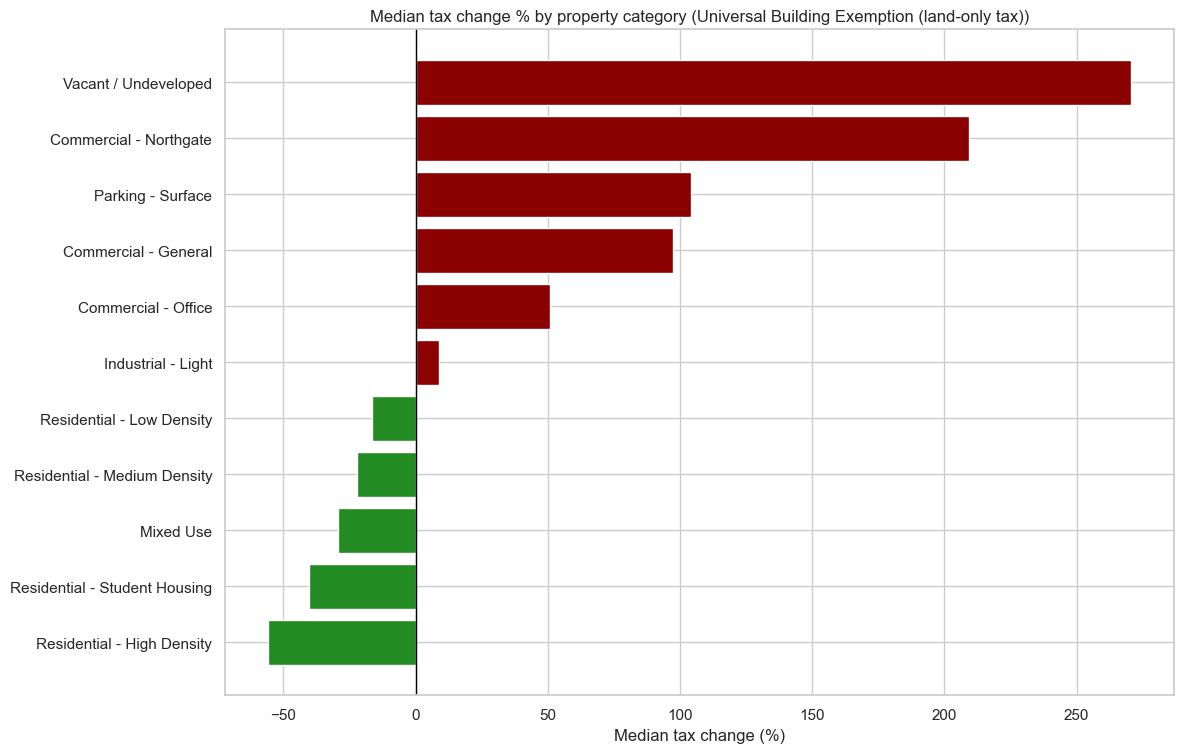

In [18]:
output_summary = calculate_category_tax_summary(
    df=primary,
    category_col="ANALYSIS_CATEGORY",
    current_tax_col="current_tax",
    new_tax_col="new_tax",
)
print_category_tax_summary(output_summary)

plot_df = (
    output_summary[output_summary["property_count"] > 20]
    .sort_values("median_tax_change_pct")
    .copy()
)
fig_height = max(5, len(plot_df) * 0.7)
plt.figure(figsize=(12, fig_height))
bar_colors = np.where(plot_df["median_tax_change_pct"] < 0, "#228B22", "#8B0000")
plt.barh(plot_df["ANALYSIS_CATEGORY"], plot_df["median_tax_change_pct"], color=bar_colors)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Median tax change % by property category ({scenario_label})")
plt.xlabel("Median tax change (%)")
plt.tight_layout()
plt.show()

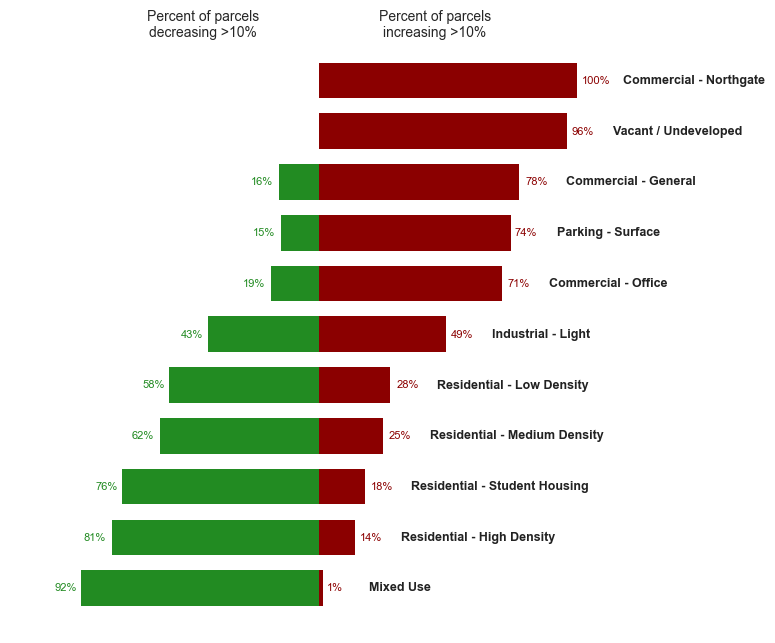

In [19]:
summary_filtered = output_summary[output_summary["property_count"] > 20].copy()
summary_sorted   = summary_filtered.sort_values("pct_increase_gt_threshold", ascending=True)

cats      = summary_sorted["ANALYSIS_CATEGORY"].tolist()
pct_inc   = summary_sorted["pct_increase_gt_threshold"].tolist()
pct_dec   = summary_sorted["pct_decrease_gt_threshold"].tolist()
pct_inc_i = [int(round(x)) for x in pct_inc]
pct_dec_i = [int(round(x)) for x in pct_dec]

y = np.arange(len(cats))
fig, ax = plt.subplots(figsize=(8, max(5, len(cats) * 0.6)))

color_inc = "#8B0000"
color_dec = "#228B22"

ax.barh(y, [-v for v in pct_dec], color=color_dec, edgecolor="none", height=0.7)
ax.barh(y, pct_inc, color=color_inc, edgecolor="none", height=0.7)

for i, (inc, dec) in enumerate(zip(pct_inc_i, pct_dec_i)):
    if dec > 0:
        ax.text(-dec - 2, y[i], f"{dec}%", va="center", ha="right", fontsize=8, color=color_dec)
    if inc > 0:
        ax.text(inc + 2, y[i], f"{inc}%", va="center", ha="left",  fontsize=8, color=color_inc)

max_val = max(max(pct_inc), max(pct_dec)) if pct_inc else 10
for i, (cat, inc) in enumerate(zip(cats, pct_inc)):
    ax.text(
        inc + 18 if inc > 0 else 18, y[i], cat,
        va="center", ha="left", fontsize=9, fontweight="bold", color="#222",
    )

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(-max_val - 20, max_val + 50)

title_y = len(cats) - 0.2
ax.text(-max_val * 0.45, title_y, "Percent of parcels\ndecreasing >10%",
        ha="center", va="bottom", fontsize=10)
ax.text( max_val * 0.45, title_y, "Percent of parcels\nincreasing >10%",
        ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## Step 7: Land-use diagnostics (vacancy, parking, low-improvement share)

In [20]:
analysis_df = primary.copy()
analysis_df["LAND_USE_FOR_ANALYSIS"] = np.select(
    [
        analysis_df["PROPERTY_CATEGORY"].str.contains("Vacant", na=False),
        analysis_df["is_osm_surface_parking"] == True,
    ],
    ["Vacant Land", "Trans - Parking"],
    default="Other",
)

vacant_results = analyze_vacant_land(
    df=analysis_df,
    land_value_col="total_land_val",
    improvement_value_col="total_imprv_val",
    property_type_col="LAND_USE_FOR_ANALYSIS",
    vacant_identifier="Vacant Land",
    owner_col="py_owner_name",
)
print_vacant_land_summary(vacant_results)

parking_results = analyze_parking_lots(
    df=analysis_df,
    land_value_col="total_land_val",
    improvement_value_col="total_imprv_val",
    property_type_col="LAND_USE_FOR_ANALYSIS",
    parking_identifier="Trans - Parking",
    min_land_value_threshold=50_000,
    max_improvement_ratio=0.10,
)
print_parking_analysis_summary(parking_results)

low_impr_share = analyze_land_by_improvement_share(
    df=analysis_df,
    land_value_col="total_land_val",
    improvement_value_col="total_imprv_val",
)
display(pd.DataFrame(low_impr_share["categories"]))

VACANT LAND ANALYSIS SUMMARY
Total vacant parcels: 4,675
Total vacant land value: $443,269,647
Average vacant land value: $94,817
Vacant land as % of total city land value: 7.1%

Ownership concentration:
Top 5% of owners control: $217,718,618 (49.1%)
Top 10% of owners control: $289,677,324 (65.4%)
PARKING LOT EFFICIENCY ANALYSIS
Total parking lots: 120
Total parking land value: $159,870,993
Average parking land value: $1,332,258
Average improvement ratio: 229.1%

Underutilized parking lots (Land value >= $50,000 and improvement ratio <= 10.0%):
Count: 3
Total land value: $9,966,956
Average land value: $3,322,319

Development potential:
Current improvement value: $0
Potential improvement value: $30,767,880
Untapped development value: $30,767,880


L:\git\LVTShift\policy_analysis.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_analysis = tier_df.groupby('land_value_tier').agg({


,category,parcel_count,adjusted_land_value,share_of_total_land_value_pct
0,0% improvement,5141,5.102082e+08,8.152831
1,<10% improvement (excl. 0%),335,1.381592e+08,2.207704
2,10-25% improvement,860,2.557252e+08,4.086341
3,25-50% improvement,2428,7.186531e+08,11.483660
4,>0%-25% improvement,1195,3.938844e+08,6.294045
5,>0%-50% improvement,3623,1.112537e+09,17.777704


## Step 7b: High-impact parcels

In [21]:
show_cols = [
    "GEO_ID", "CITY", "py_owner_name", "imprv_state_cd", "ANALYSIS_CATEGORY",
    "total_land_val", "total_imprv_val",
    "current_tax", "new_tax", "tax_change", "tax_change_pct",
]
available = [c for c in show_cols if c in primary.columns]
top_increase = primary.nlargest(20,  "tax_change")[available]
top_decrease = primary.nsmallest(20, "tax_change")[available]

print("Top 20 increases")
display(top_increase)
print("Top 20 decreases")
display(top_decrease)

Top 20 increases


,GEO_ID,CITY,py_owner_name,imprv_state_cd,ANALYSIS_CATEGORY,total_land_val,total_imprv_val,current_tax,new_tax,tax_change,tax_change_pct
38697,005001-1041-0018,COLLEGE STATION,CENTURY SQUARE COMMERCIAL VENTURE LLC,F1,Commercial - General,13585048.0,9253647.0,435504.680120,9.890315e+05,553526.815044,127.100084
48707,514000-0001-0040,COLLEGE STATION,POM-COLLEGE STATION LLC,F1,Commercial - General,15252840.0,16747160.0,610199.040000,1.110452e+06,500252.623528,81.981877
58215,005001-1041-0022,COLLEGE STATION,MIDWAY HOSPITALITY LP,,Vacant / Undeveloped,7034208.0,0.0,134133.342774,5.121111e+05,377977.711640,281.792509
29746,005001-1100-0050,COLLEGE STATION,CULPEPPER FAMILY LP,,Parking - Surface,6975000.0,0.0,133004.322000,5.078005e+05,374796.215677,281.792509
40290,555000-0032-0040,BRYAN,OAKWOOD MHC LP,F1,Commercial - General,5804666.0,8986668.0,75039.110738,4.280944e+05,353055.290228,470.495035
16983,558300-0001-0010,COLLEGE STATION,SAMS CLUB EAST #6338,F1,Commercial - General,6969600.0,1517399.0,161836.207571,5.074074e+05,345571.194206,213.531446
31343,661500-0000-0090,COLLEGE STATION,5B MANAGEMENT LLC,F1,Commercial - General,4566985.0,1268754.0,55034.881128,3.324900e+05,277455.074221,504.144042
28371,391300-0001-0010,COLLEGE STATION,LONE STAR PAVILION LLC,F1,Commercial - General,8082980.0,8747234.0,320930.638306,5.884647e+05,267534.105785,83.361971
48156,538900-0000-0010,COLLEGE STATION,111 EUCS LTD,F1,Commercial - General,4850625.0,2645588.0,97166.455220,3.531398e+05,255973.327299,263.437960
54845,413600-0101-0020,COLLEGE STATION,COSTCO WHOLESALE CORPORATION,F1,Parking - Surface,6099489.0,4506153.0,202236.017718,4.440608e+05,241824.741243,119.575506


Top 20 decreases


,GEO_ID,CITY,py_owner_name,imprv_state_cd,ANALYSIS_CATEGORY,total_land_val,total_imprv_val,current_tax,new_tax,tax_change,tax_change_pct
18586,610720-0000-0001,COLLEGE STATION,COLLEGE STATION PROPERTIES KP6 LLC,B1,Residential - Student Housing,2858625.0,106141375.0,2.078490e+06,208116.317135,-1.870374e+06,-89.987141
39825,584170-0001-0010,COLLEGE STATION,SO COLLEGE STATION APARTMENTS LP,B1,Residential - Student Housing,6540534.0,102459466.0,2.078490e+06,476170.133605,-1.602320e+06,-77.090579
36935,144500-0013-0130,COLLEGE STATION,COLLEGE STATION PROPERTIES II KP6 LLC,B1,Residential - Student Housing,5902925.0,100097075.0,2.021284e+06,429750.320985,-1.591534e+06,-78.738750
45252,144500-0012-0120,COLLEGE STATION,THE STANDARD AT COLLEGE STATION LLC,B1,Residential - Student Housing,5853500.0,82146500.0,1.678047e+06,426152.035454,-1.251895e+06,-74.604290
35627,604806-0101-0020,COLLEGE STATION,CLPF COTTAGES LP,B1,Residential - Student Housing,8516669.0,74098287.0,1.575361e+06,620038.580275,-9.553229e+05,-60.641504
40816,604806-0201-0010,COLLEGE STATION,2025 STUDENT LL LLC,B1,Residential - Student Housing,1898046.0,49865267.0,9.870601e+05,138183.337539,-8.488768e+05,-86.000515
39985,567470-0001-0010,COLLEGE STATION,TAM THE RISE PROPERTY LLC,B1,Residential - Student Housing,3376641.0,53623359.0,1.086917e+06,245829.407218,-8.410876e+05,-77.382873
54854,114500-0001-0010,COLLEGE STATION,CS HARVEY LTD,B1,Residential - Student Housing,1693688.0,44306312.0,8.771611e+05,123305.473413,-7.538556e+05,-85.942665
50671,659400-0001-0010,COLLEGE STATION,TGAP UNIVERSITY TRAILS OWNER LLC,B1,Residential - Student Housing,2138944.0,44681056.0,8.927975e+05,155721.421256,-7.370760e+05,-82.558035
49345,174100-0201-0010,COLLEGE STATION,ACC OP (CALLAWAY VILLAS) LP,B1,Residential - Student Housing,2975366.0,47024634.0,9.534360e+05,216615.405676,-7.368206e+05,-77.280551


## Step 8: Census equity analysis

L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),27.0,-7.932411,-15.588489,23025.703704
1,Q2,26.0,22.017823,19.338152,38223.730769
2,Q3,26.0,12.207212,-6.196707,52928.923077
3,Q4,26.0,5.264349,1.805350,74330.615385
4,Q5 (Highest),26.0,2.682741,-9.135888,126799.961538


,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),3.0,-60.642217,-59.573441,17797.000000
1,Q2,3.0,-24.001219,-9.526362,27516.333333
2,Q3,3.0,-17.751320,-23.580229,33511.000000
3,Q4,3.0,-29.144677,-32.063579,44239.000000
4,Q5 (Highest),3.0,30.959368,30.696223,80937.666667


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),27.0,14.022607,7.686323,18.854444
1,Q2,26.0,-1.482220,-11.812068,34.780385
2,Q3,26.0,2.441044,-1.931689,44.736923
3,Q4,26.0,-5.266205,-11.378642,63.266923
4,Q5 (Highest),26.0,23.680066,12.177150,88.626923


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),3.0,36.970640,30.696223,29.123333
1,Q2,3.0,-31.751148,-56.439314,45.886667
2,Q3,3.0,-20.007335,-27.560178,51.003333
3,Q4,3.0,-42.199732,-32.063579,66.923333
4,Q5 (Highest),3.0,-43.592490,-56.773497,80.663333


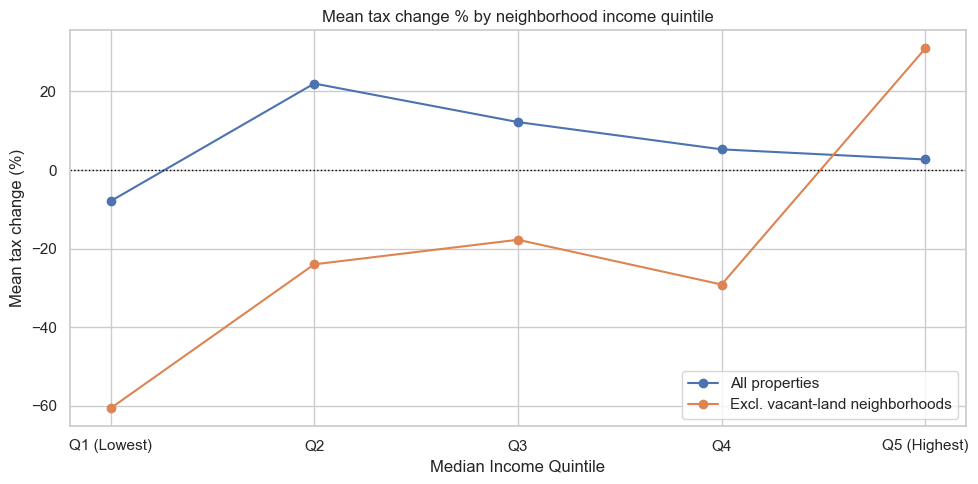

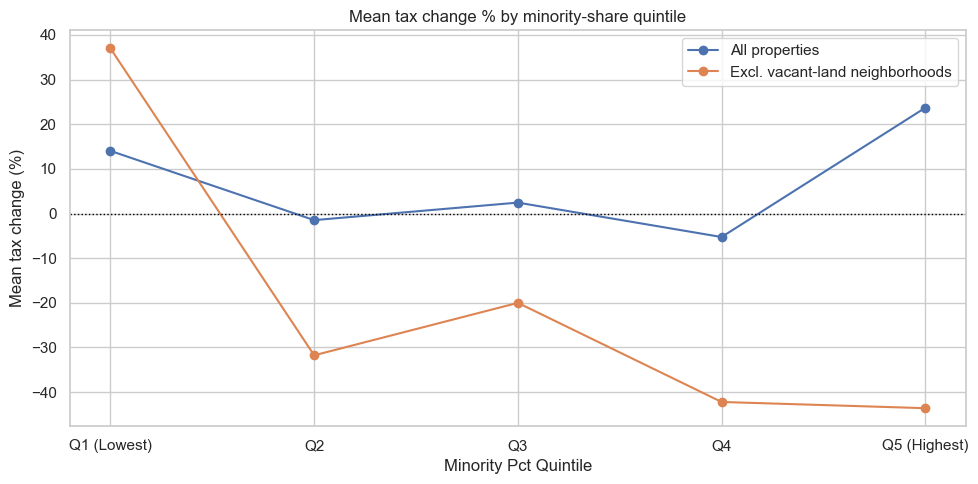

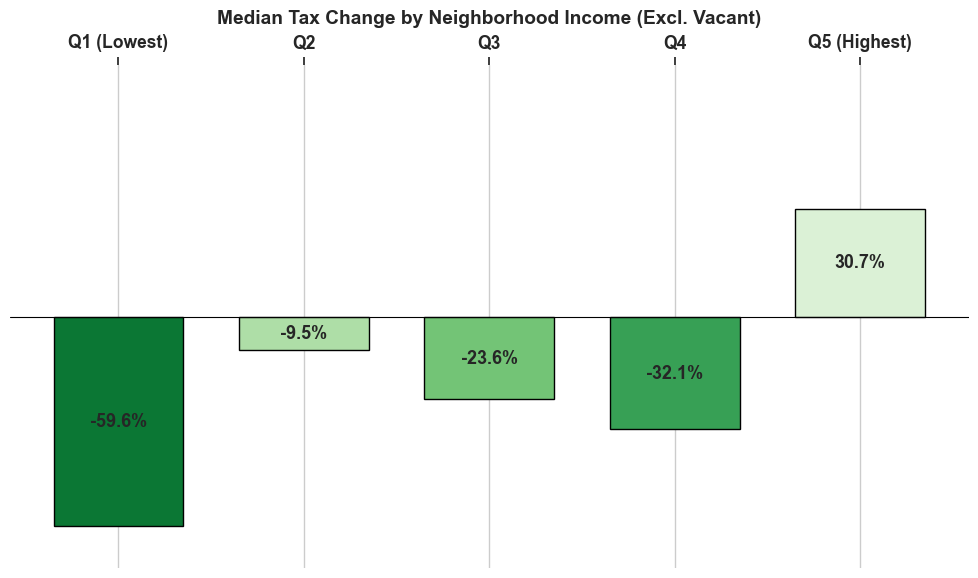

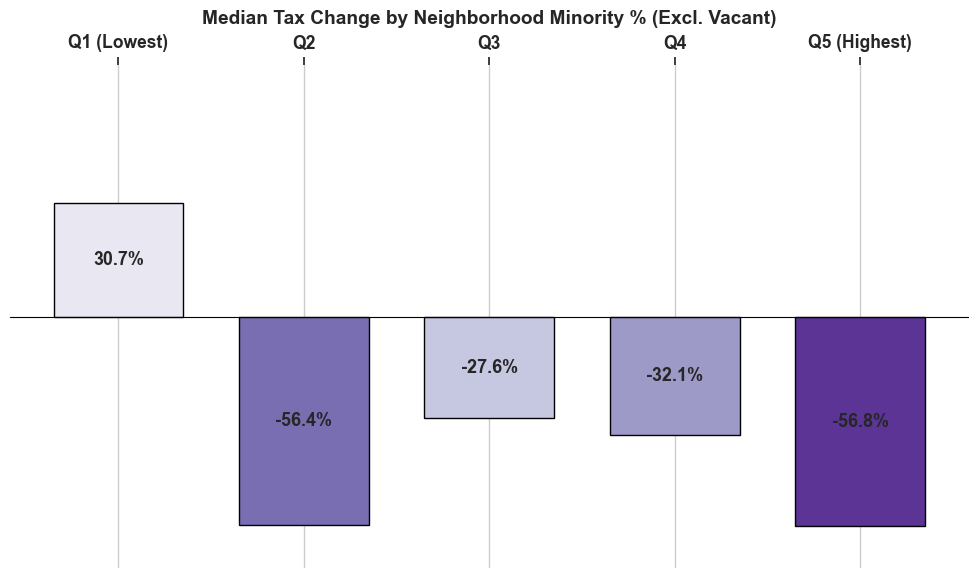

L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

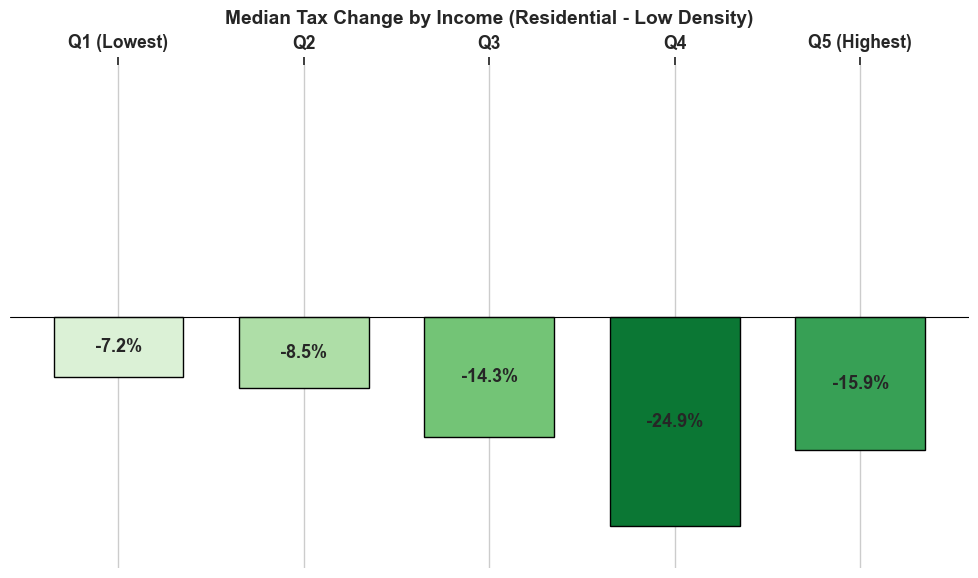

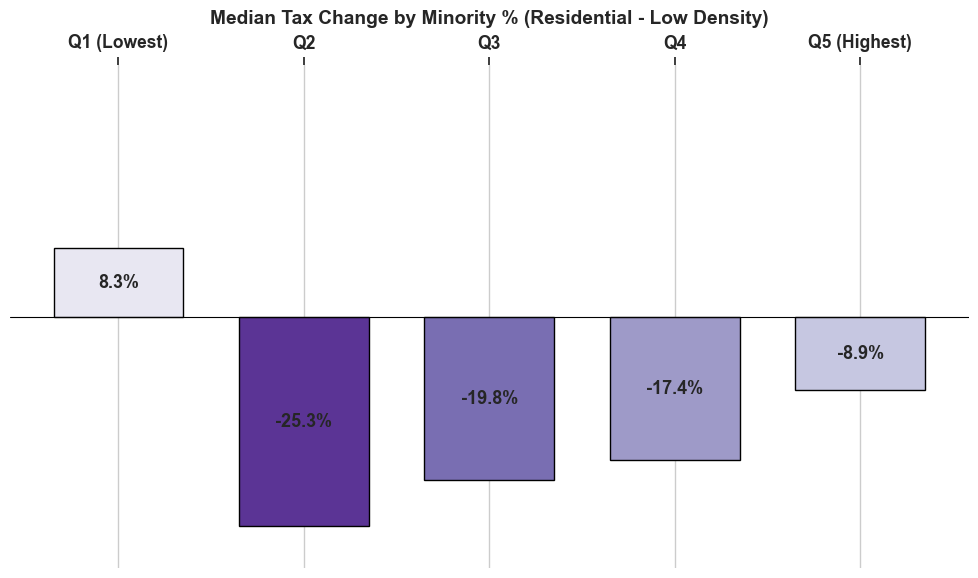

L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

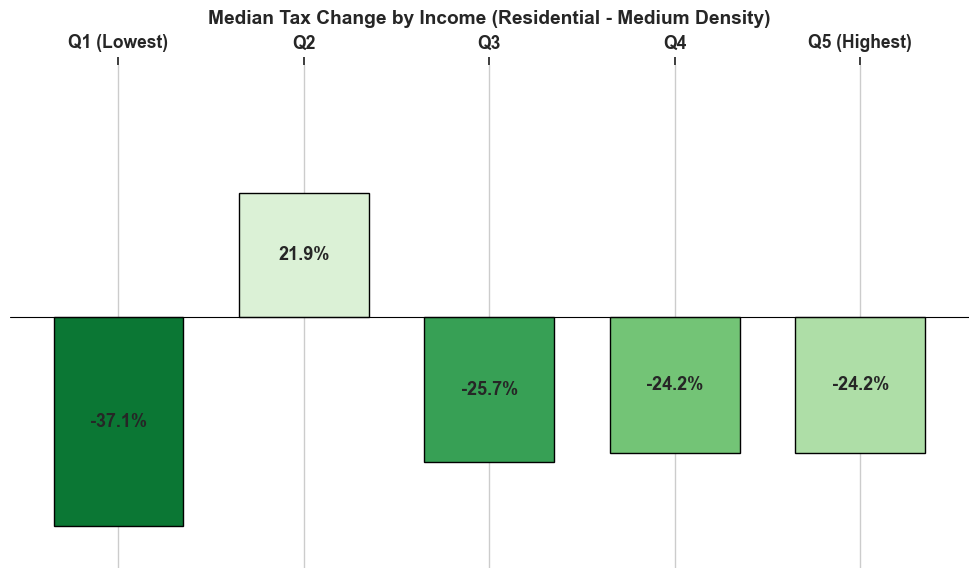

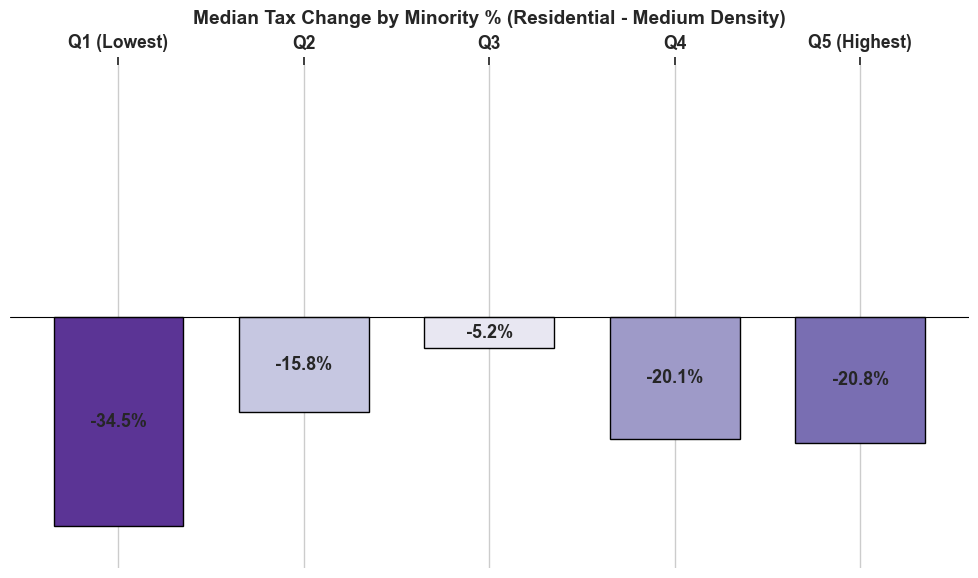

L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

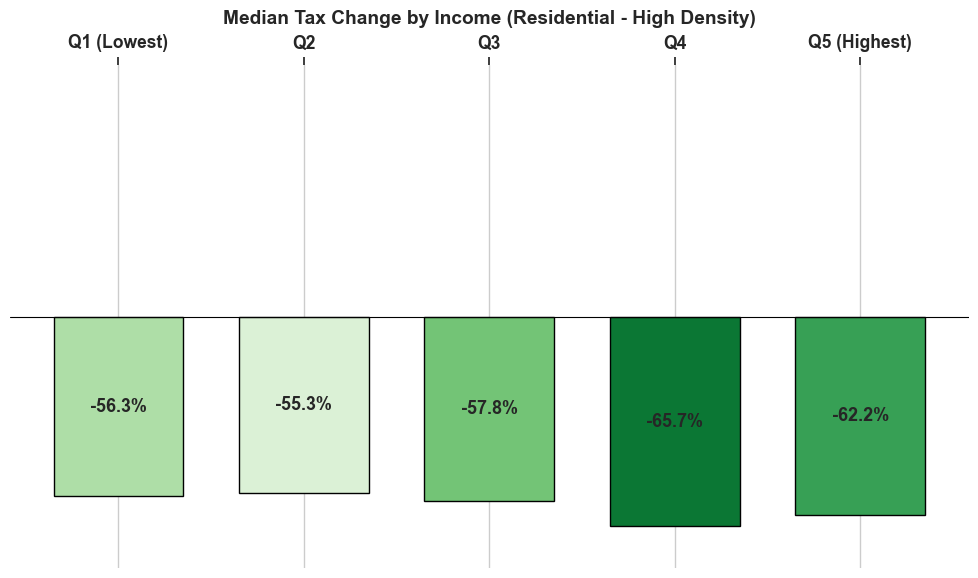

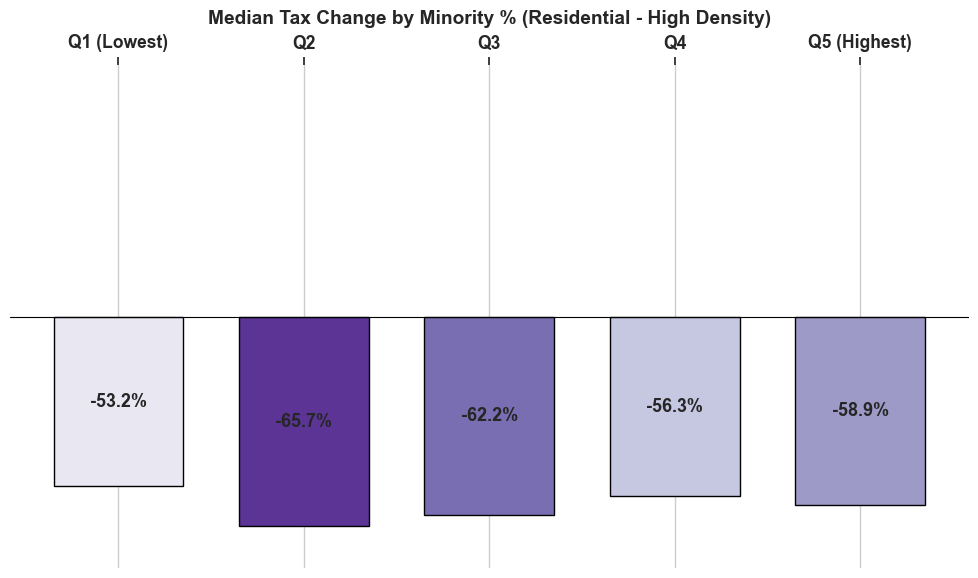

L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

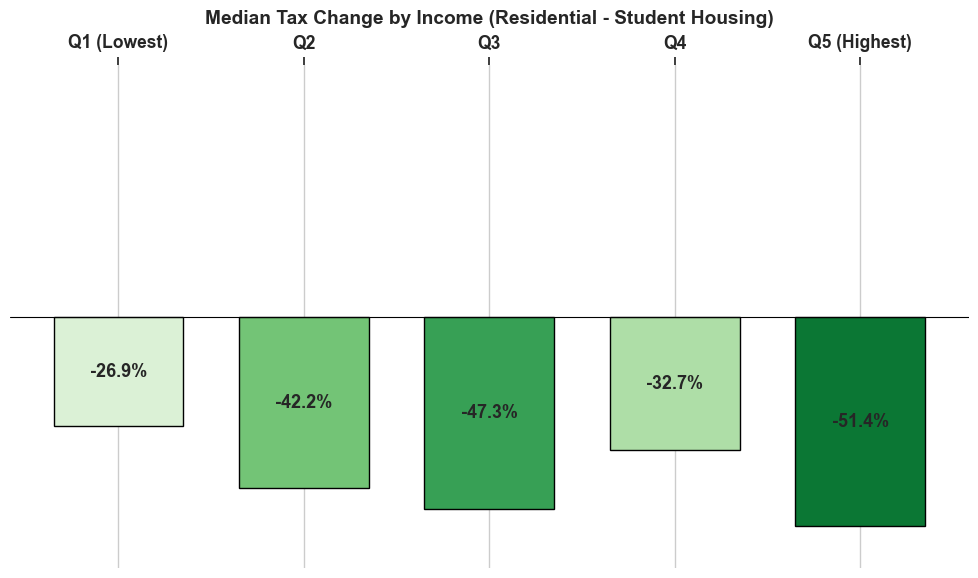

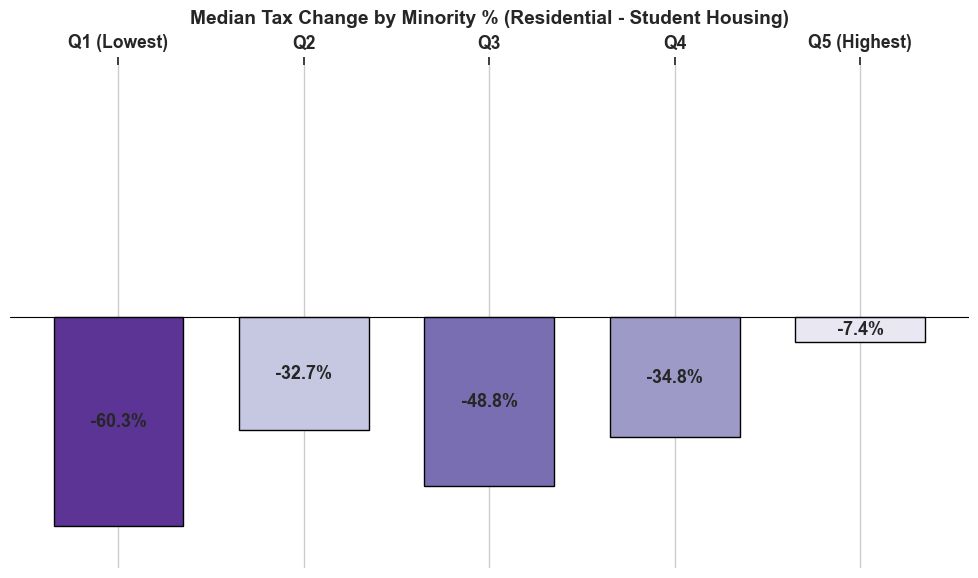

L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
L:\git\LVTShift\viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

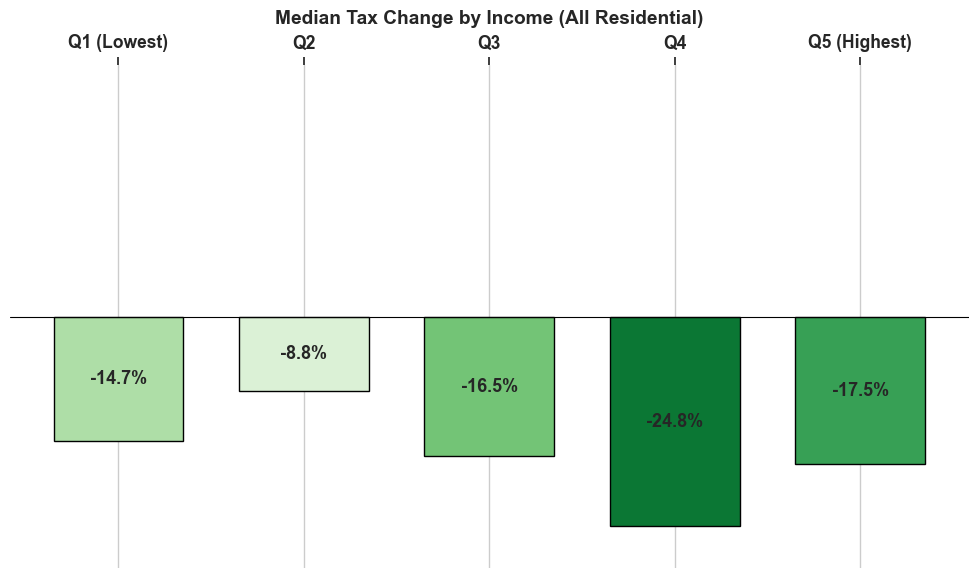

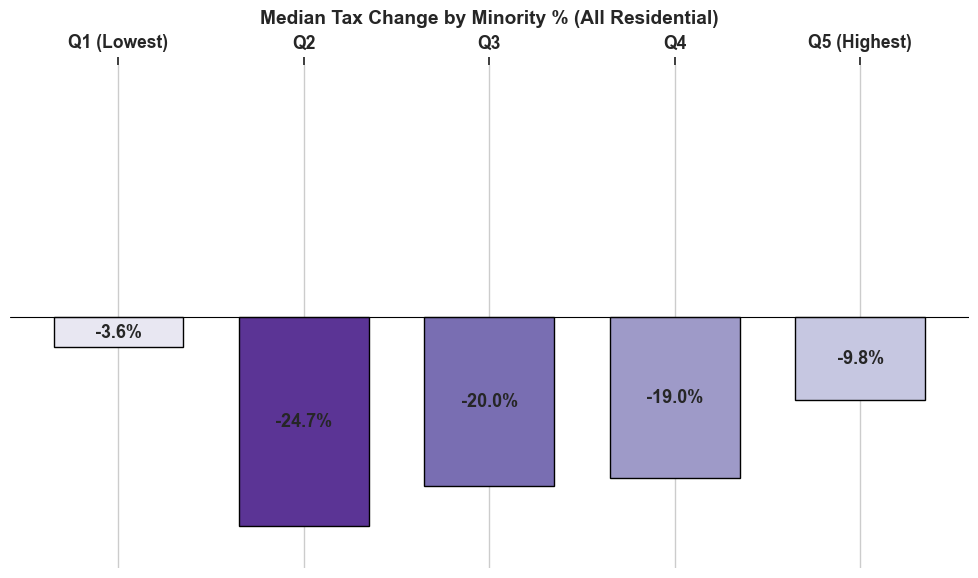

In [22]:
equity_df = primary.copy().to_crs(epsg=4326)

try:
    census_data, census_boundaries = get_census_data_with_boundaries(
        fips_code=BRAZOS_COUNTY_FIPS,
        year=2022,
    )
    matched = match_to_census_blockgroups(equity_df, census_boundaries, join_type="left")
    matched = matched[matched["median_income"] > 0].copy()

    bg_summary = (
        matched.groupby("std_geoid")
        .agg(
            median_income       =("median_income",    "first"),
            minority_pct        =("minority_pct",     "first"),
            total_current_tax   =("current_tax",      "sum"),
            total_new_tax       =("new_tax",           "sum"),
            mean_tax_change     =("tax_change",        "mean"),
            median_tax_change   =("tax_change",        "median"),
            median_tax_change_pct=("tax_change_pct",  "median"),
            parcel_count        =("GEO_ID",            "count"),
            has_vacant_land     =("ANALYSIS_CATEGORY", lambda x: (x == "Vacant / Undeveloped").any()),
        )
        .reset_index()
    )
    bg_summary = bg_summary[bg_summary["median_income"] > 0].copy()
    bg_summary["mean_tax_change_pct"] = np.where(
        bg_summary["total_current_tax"] > 0,
        (bg_summary["total_new_tax"] - bg_summary["total_current_tax"])
        / bg_summary["total_current_tax"] * 100,
        0,
    )
    non_vacant_bg = bg_summary[~bg_summary["has_vacant_land"]].copy()

    income_q    = create_quintile_summary(bg_summary,    "median_income", "median_income", "mean_tax_change", "mean_tax_change_pct")
    nv_income_q = create_quintile_summary(non_vacant_bg, "median_income", "median_income", "mean_tax_change", "mean_tax_change_pct")
    minority_q  = create_quintile_summary(bg_summary,    "minority_pct",  "minority_pct",  "mean_tax_change", "mean_tax_change_pct")
    nv_minor_q  = create_quintile_summary(non_vacant_bg, "minority_pct",  "minority_pct",  "mean_tax_change", "mean_tax_change_pct")

    display(income_q)
    display(nv_income_q)
    display(minority_q)
    display(nv_minor_q)

    # Line charts
    for q_all, q_nv, x_col, title in [
        (income_q,   nv_income_q, "median_income_quintile",
         "Mean tax change % by neighborhood income quintile"),
        (minority_q, nv_minor_q,  "minority_pct_quintile",
         "Mean tax change % by minority-share quintile"),
    ]:
        plt.figure(figsize=(10, 5))
        plt.plot(q_all[x_col], q_all["mean_tax_change_pct"], marker="o", label="All properties")
        plt.plot(q_nv[x_col],  q_nv["mean_tax_change_pct"],  marker="o",
                 label="Excl. vacant-land neighborhoods")
        plt.axhline(0, color="black", linewidth=1, linestyle="dotted")
        plt.title(title)
        plt.xlabel(x_col.replace("_", " ").title())
        plt.ylabel("Mean tax change (%)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Inverted bar charts (median, excl. vacant)
    sns.set_theme(style="whitegrid", font_scale=1.15)

    def inverted_bar(quintile_df, lbl_col, palette, title):
        fig, ax = plt.subplots(figsize=(10, 6))
        vals      = quintile_df["median_tax_change_pct"]
        labels    = quintile_df[lbl_col]
        colors    = sns.color_palette(palette, n_colors=len(vals))
        color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]
        bars      = ax.bar(labels, vals, color=color_map, edgecolor="black", width=0.7)
        ax.yaxis.set_visible(False)
        ax.set_title(title, weight="bold", pad=30)
        sns.despine(left=True, right=True, top=True, bottom=True)
        for bar, val in zip(bars, vals):
            ax.annotate(
                f"{val:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, val / 2),
                ha="center", va="center", fontsize=13, fontweight="bold",
            )
        ax.xaxis.set_ticks_position("top")
        ax.xaxis.set_label_position("top")
        plt.xticks(fontweight="bold")
        margin = max(abs(vals.min()), abs(vals.max())) * 1.2 if len(vals) else 1
        ax.set_ylim(-margin, margin)
        ax.axhline(y=0, color="black", linewidth=0.8)
        plt.tight_layout()
        plt.show()

    inverted_bar(nv_income_q, "median_income_quintile", "Greens",
                 "Median Tax Change by Neighborhood Income (Excl. Vacant)")
    inverted_bar(nv_minor_q,  "minority_pct_quintile",  "Purples",
                 "Median Tax Change by Neighborhood Minority % (Excl. Vacant)")

    # Subgroup quintile charts
    def render_quintile_bars(df_subset, title_prefix):
        if len(df_subset) < 25:
            print(f"Skipping {title_prefix}: too few parcels ({len(df_subset)}).")
            return
        inc   = create_quintile_summary(df_subset, "median_income", "median_income",
                                        "tax_change", "tax_change_pct")
        minor = create_quintile_summary(df_subset, "minority_pct",  "minority_pct",
                                        "tax_change", "tax_change_pct")
        for summ, lbl_col, palette, ttl in [
            (inc,   "median_income_quintile", "Greens",
             f"Median Tax Change by Income ({title_prefix})"),
            (minor, "minority_pct_quintile",  "Purples",
             f"Median Tax Change by Minority % ({title_prefix})"),
        ]:
            inverted_bar(summ, lbl_col, palette, ttl)

    render_quintile_bars(
        matched[matched["ANALYSIS_CATEGORY"].str.contains("Low Density",    na=False)],
        "Residential - Low Density",
    )
    render_quintile_bars(
        matched[matched["ANALYSIS_CATEGORY"].str.contains("Medium Density", na=False)],
        "Residential - Medium Density",
    )
    render_quintile_bars(
        matched[matched["ANALYSIS_CATEGORY"].str.contains("High Density",   na=False)],
        "Residential - High Density",
    )
    render_quintile_bars(
        matched[matched["ANALYSIS_CATEGORY"].str.contains("Student",        na=False)],
        "Residential - Student Housing",
    )
    render_quintile_bars(
        matched[matched["PROPERTY_CATEGORY"].str.contains("Residential",    na=False)],
        "All Residential",
    )

except Exception as exc:
    print("Census equity analysis skipped:", exc)
    print("Set CENSUS_API_KEY in .env and rerun this cell.")